# Transport Model For An Agricultural Catchment


In [2]:
# -*- coding: utf-8 -*-
"""
Created on Fri Mar 21 10:39:38 2025

@author: Ronan
"""



'\nCreated on Fri Mar 21 10:39:38 2025\n\n@author: Ronan\n'

In [ ]:
# Libraries installed by default
import sys
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import glob
import pickle
import matplotlib.dates as mdates
import rasterio
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from itertools import islice
from mpl_toolkits.axes_grid1 import make_axes_locatable

import imageio
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

# Add
import flopy.utils.binaryfile as bf
from PIL import Image

# ROOT DIRECTORY
from os.path import dirname, abspath
try:
    root_dir = '/home/bb/Documents/01_Git_Repository/01-HydroModPy-dev'
except NameError:
    root_dir = os.getcwd()
sys.path.append(root_dir)

# HYDROMODPY MODULES
from hydromodpy import watershed_root
from hydromodpy.display import visualization_watershed, visualization_results
from hydromodpy.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20)  # small, medium, interm, large



In [4]:

regression_path = os.path.join(root_dir, "examples", "09_transport_model_for_an_agricultural_catchment/")
data_path = os.path.join(regression_path, "data/")

# The folder out_path is created in the example_path root directory:
out_path = os.path.join(root_dir, "examples", "results")
# Or define it manually
# out_path = 'C:/Simulations/HydroModPy/'

print('The results of the example will be saved here :', out_path)



The results of the example will be saved here : /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results


In [5]:

dem_path = data_path + 'bdalti25m_naizin_regional_v0.tif'
load = False
watershed_name = 'Example_09_Naizin'
from_lib = None # os.path.join(root_dir,'watershed_library.csv')
from_dem = None # [path, cell size]
from_shp = None # [path, buffer size]
from_xyv = [265545.208,6783317.640, 50, 20 , 'EPSG:2154'] # [x, y, snap distance, buffer size, crs proj]
bottom_path = None # path
save_object = True



In [ ]:

print('##### '+watershed_name.upper()+' #####')

load = load
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=from_lib, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=from_dem, # [path, cell size]
                              from_shp=from_shp, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              bottom_path=bottom_path, # path
                              save_object=save_object)

# Paths generated automatically but necessary for plots
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'
calibration_folder = out_path+'/'+watershed_name+'/'+'results_calibration/'



[INFO]       __  __          __           __  ____          ________     
[INFO]      / / / /         / /          /  \/   /         / / __  /     
[INFO]     / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
[INFO]    / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
[INFO]   / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
[INFO]  /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
[INFO]        /____/ Hydrological Modelling in Python /_____________/    
[INFO]                                                                   
[INFO] Initializing watershed object from scratch as requested
[INFO] Extracting geographic data for model area


##### EXAMPLE_09_NAIZIN #####


[INFO] Extracting hydrography data from /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/09_transport_model_for_an_agricultural_catchment/data/
[INFO] Extracting subbasin definitions for watershed


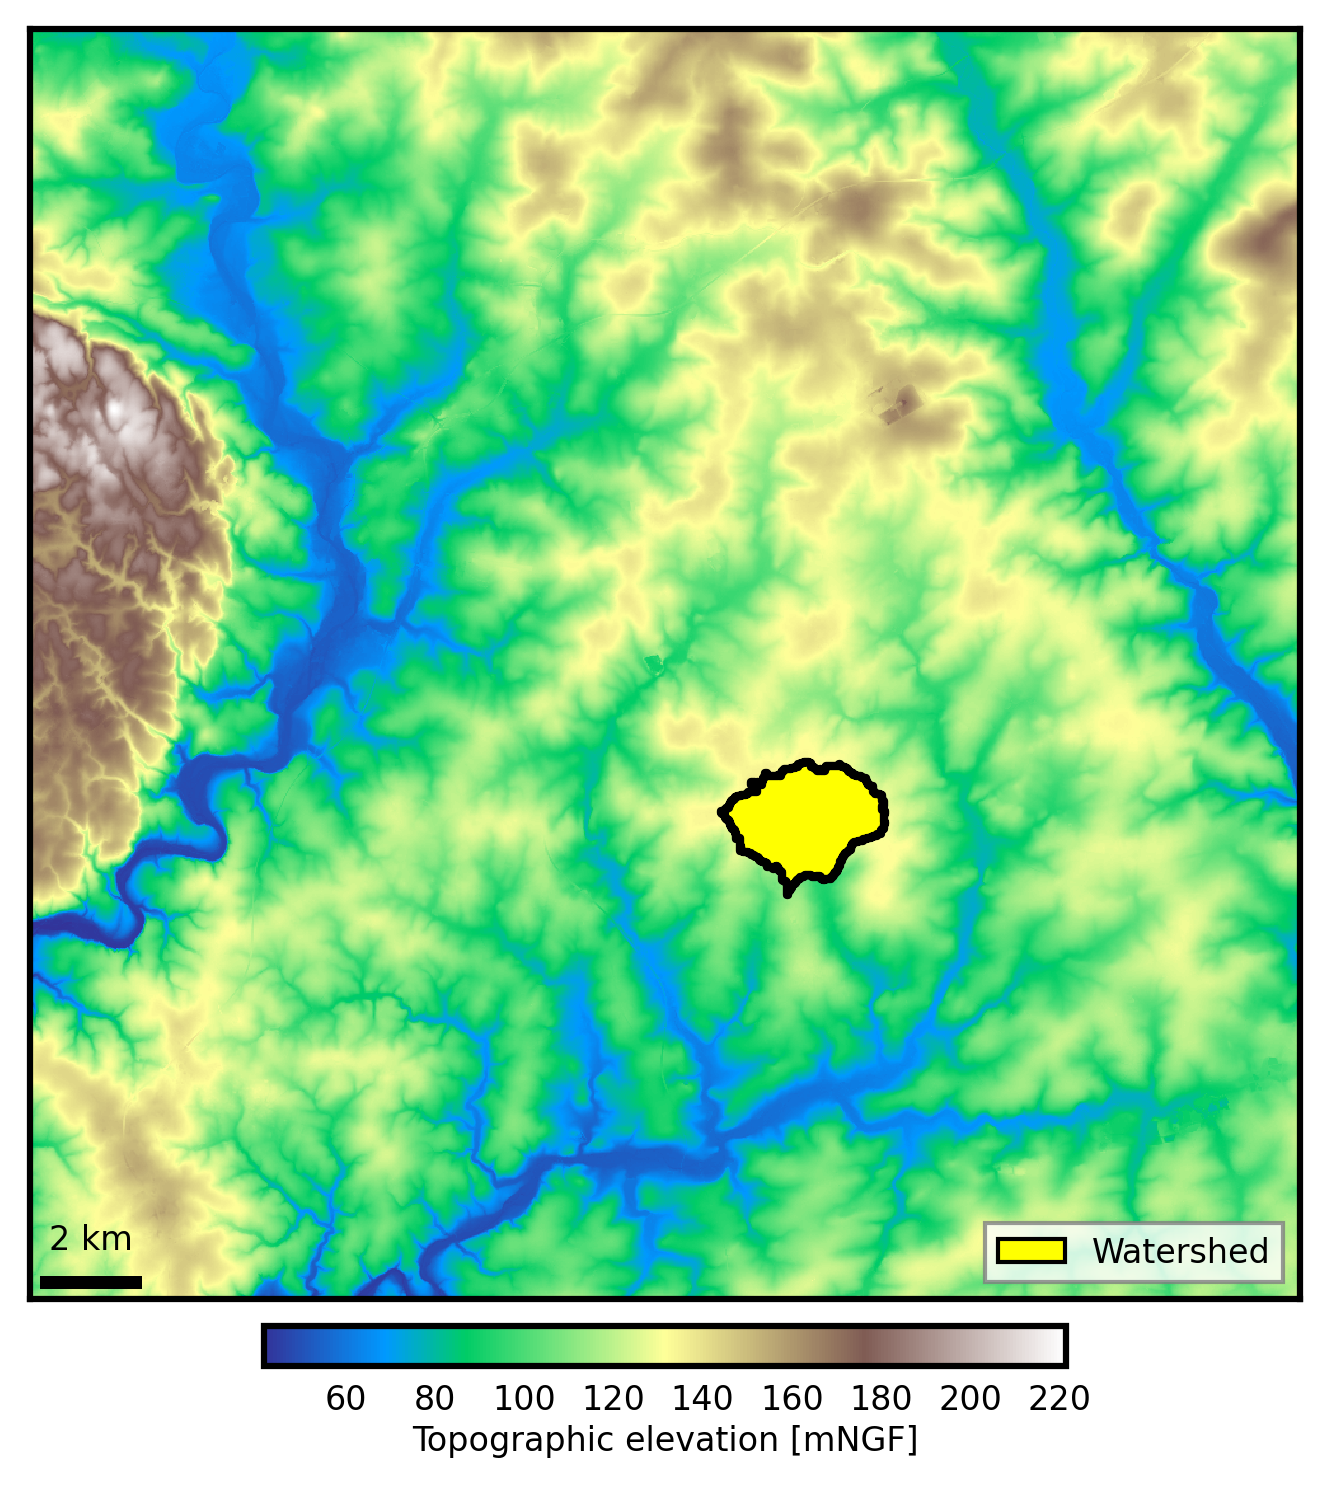

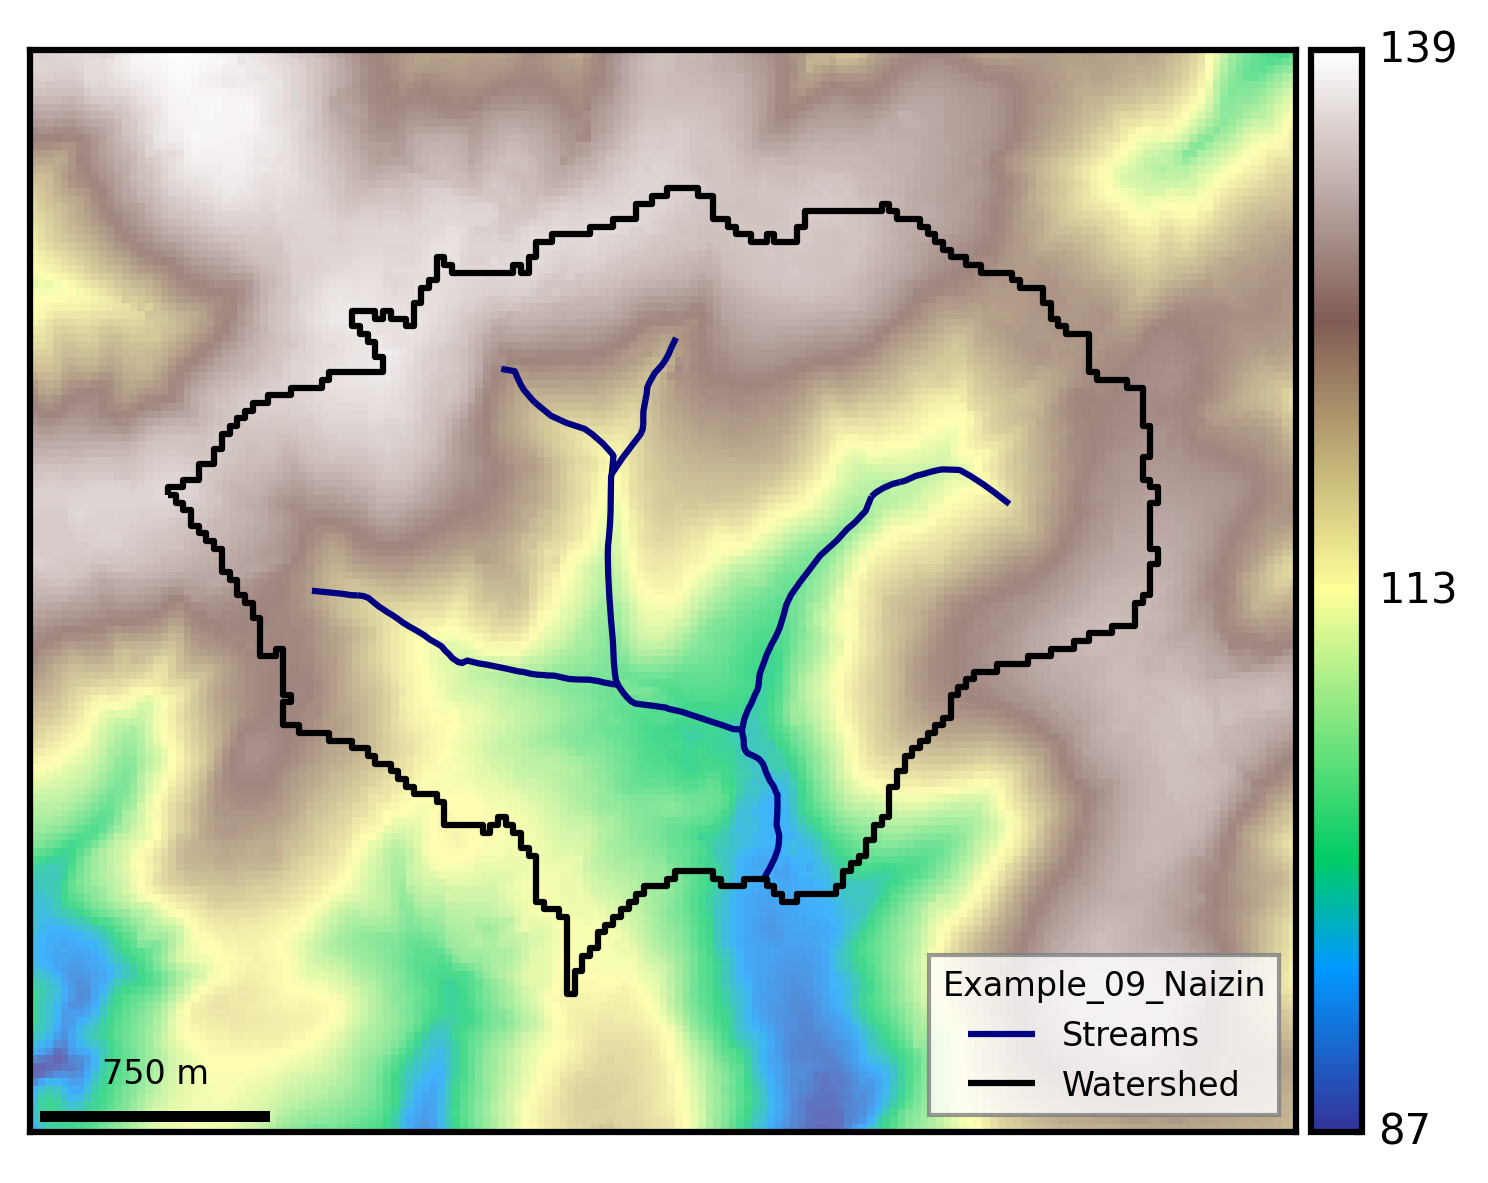

In [7]:

BV.add_hydrography(data_path , types_obs=['botopage2024_naizin_streams_perennial-intermittent'], fields_obs=['FID'])
BV.add_subbasin(data_path, 50)

visualization_watershed.watershed_local(dem_path, BV)
visualization_watershed.watershed_dem(BV)

area = BV.geographic.area



[INFO] Initializing climatic module parameters


Text(0.5, 1.0, 'Synthetic recharge [mm/week]')

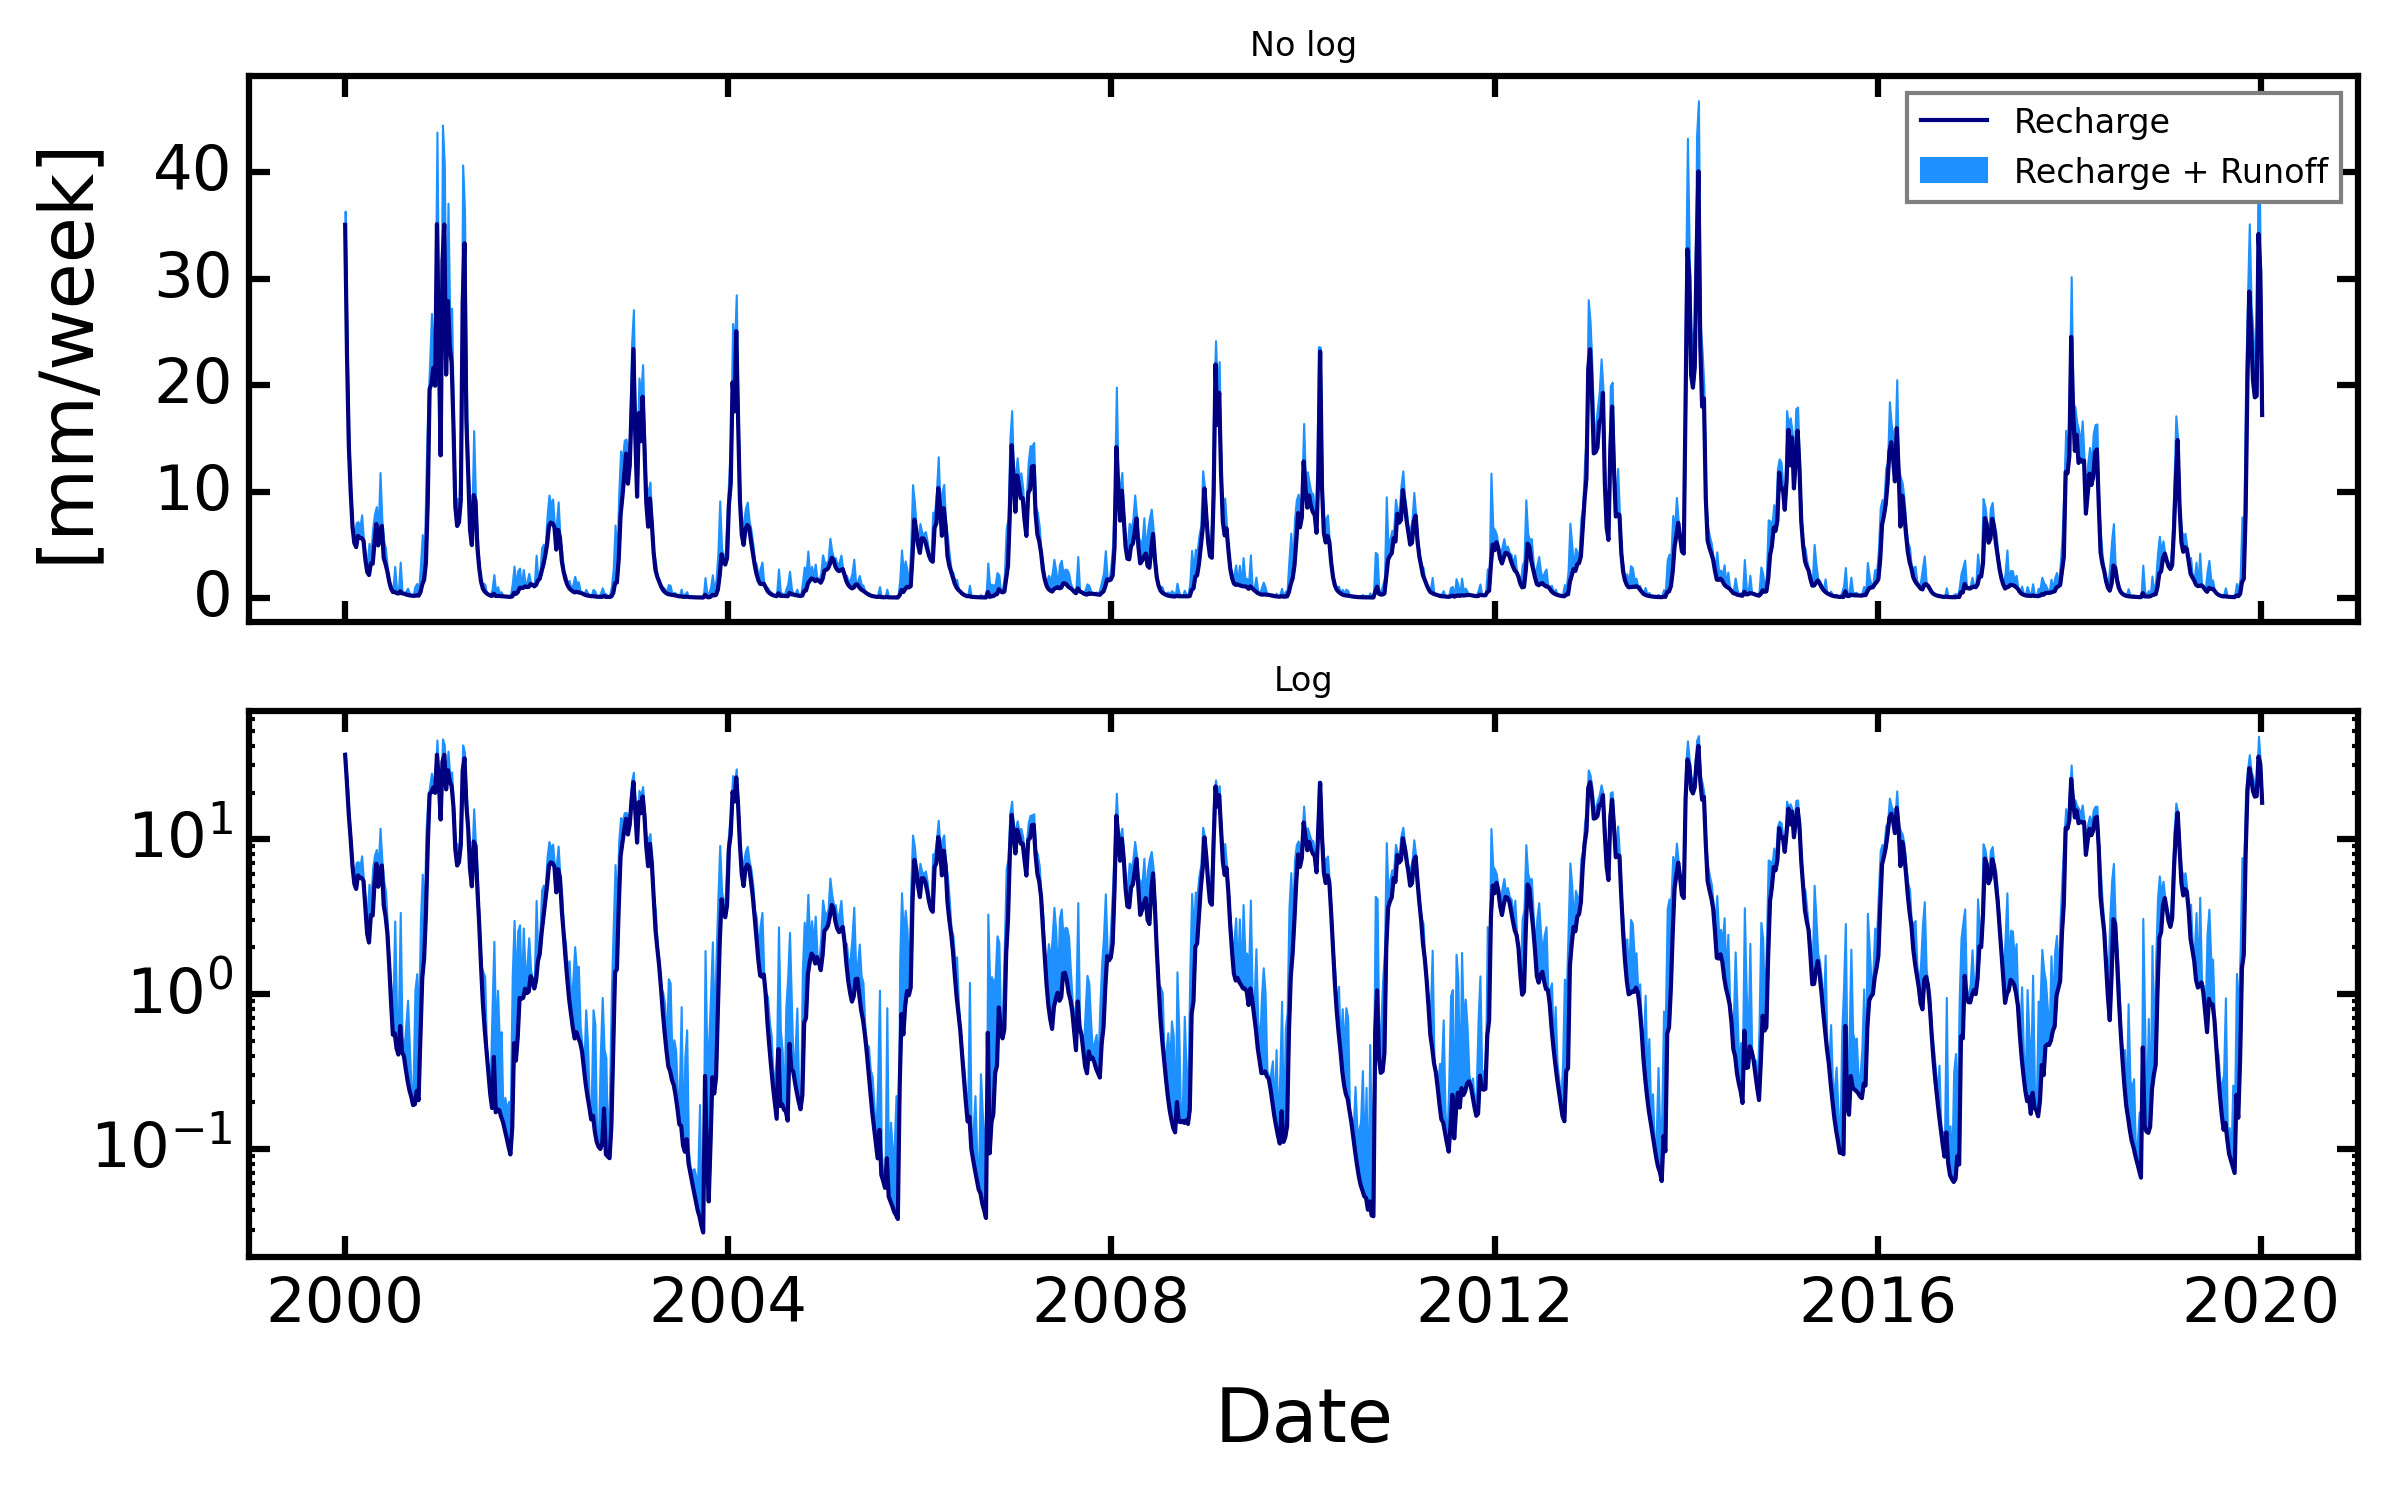

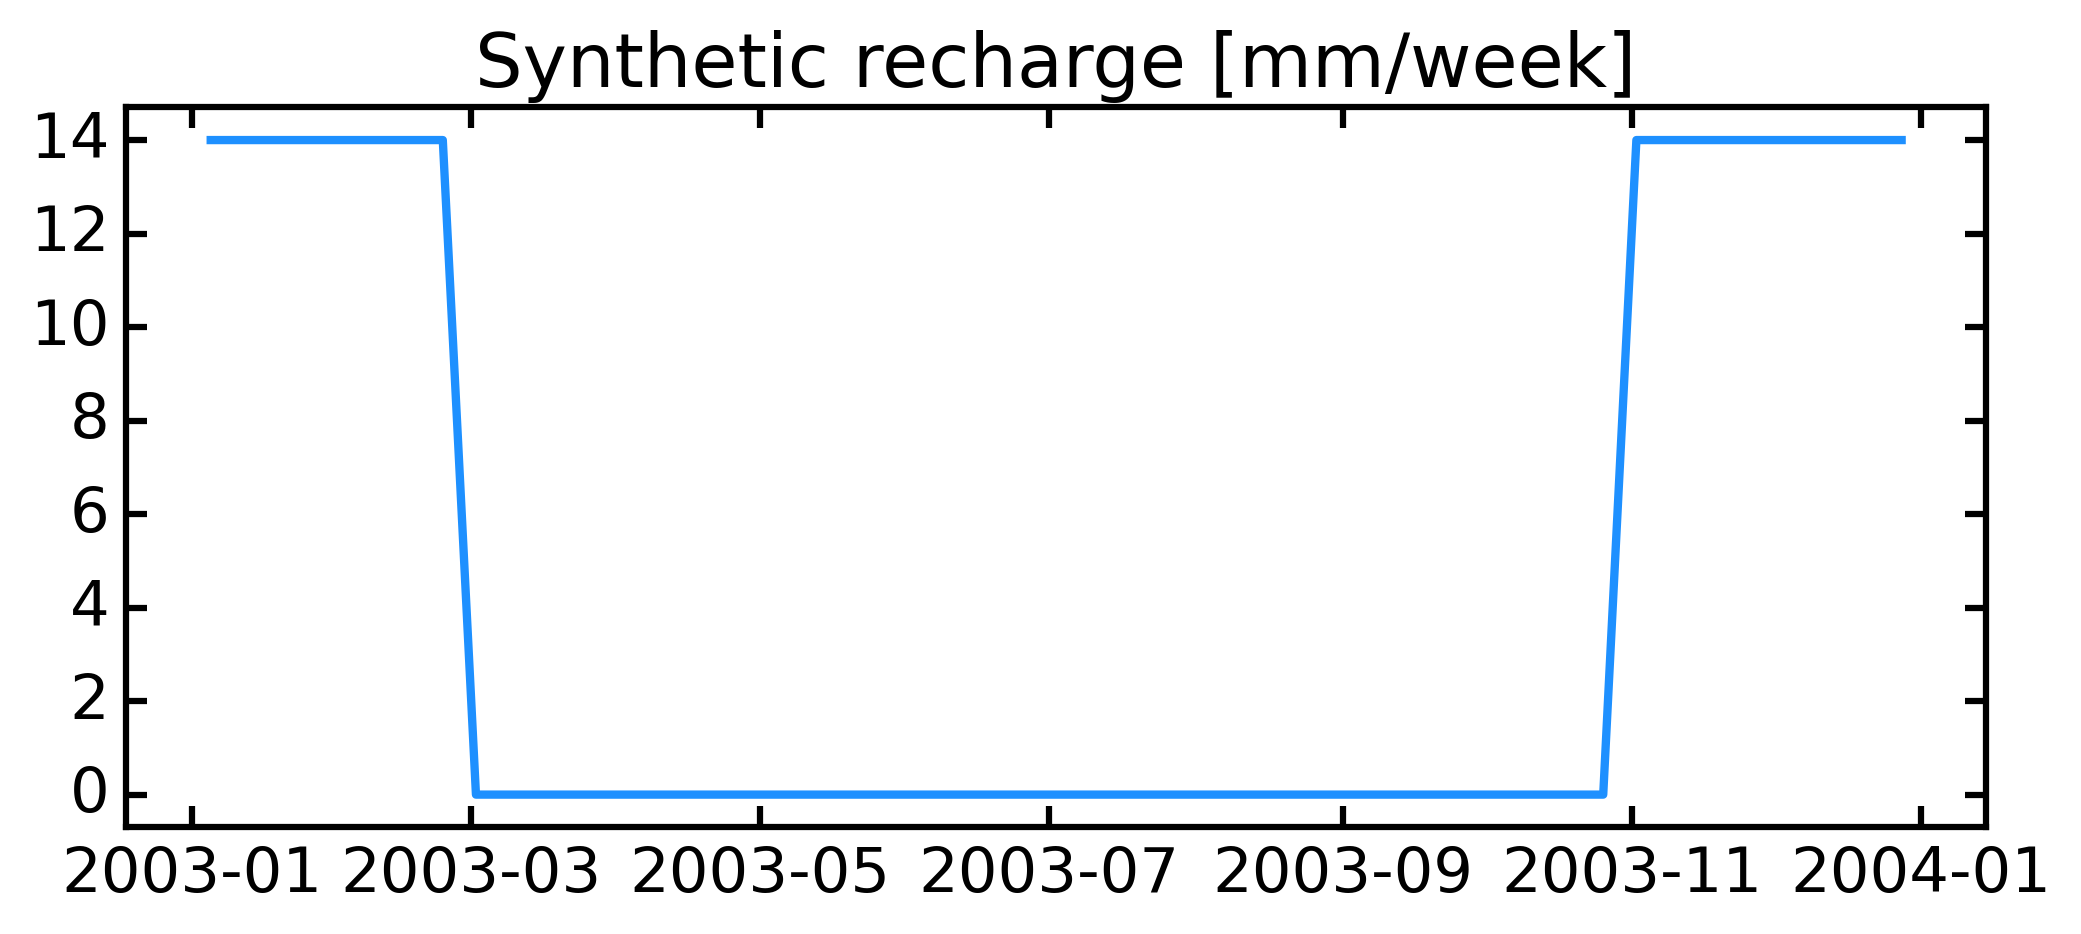

In [8]:

# Necessary to set model parameters
BV.add_climatic()

# BV.climatic.update_sim2_reanalysis(var_list=['recharge', 'runoff',],
#                                         nc_data_path=data_path,
#                                         first_year=1990,
#                                         # last_year=2002,
#                                         time_step='D',
#                                         sim_state='transient',
#                                         spatial_mean=True,
#                                         geographic=BV.geographic,
#                                         disk_clip='watershed')

BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                        clim_mod='REA',
                                        clim_sce='historic',
                                        first_year=2000,
                                        last_year=2019,
                                        time_step='W',
                                        sim_state='transient')

BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                      clim_mod='REA',
                                      clim_sce='historic',
                                      first_year=2000,
                                      last_year=2019,
                                      time_step='W',
                                      sim_state='transient')

def select_period(df, first, last):
    df = df[(df.index.year>=first) & (df.index.year<=last)]
    return df

R_mm_day = BV.climatic.recharge
r_mm_day = BV.climatic.runoff

fig, axs = plt.subplots(2,1, figsize=(8,5), sharex=True)
axs = axs.ravel()

ax = axs[0]
ax.plot(7*R_mm_day, label='Recharge', c='navy', lw=1)
ax.fill_between(R_mm_day.index, 7*R_mm_day, (7*R_mm_day)+(7*r_mm_day), label='Recharge + Runoff', color='dodgerblue', lw=0.5, alpha=1)
ax.set_ylabel('[mm/week]')
ax.legend(loc='upper right')
ax.set_title('No log', fontsize=8)

ax = axs[1]
ax.plot(7*R_mm_day, label='Recharge', c='navy', lw=1)
ax.fill_between(R_mm_day.index, 7*R_mm_day, (7*R_mm_day)+(7*r_mm_day), label='Recharge + Runoff', color='dodgerblue', lw=0.5, alpha=1)
ax.set_yscale('log')
ax.set_xlabel('Date')
ax.set_title('Log', fontsize=8)

# Save plot as PNG
fig.tight_layout()

R_mm_day_filt = select_period(R_mm_day, 2003, 2003)*0
R_mm_day_filt[R_mm_day_filt.index.month.isin([3,4,5,6,7,8,9,10])] = 0
R_mm_day_filt[R_mm_day_filt.index.month.isin([1,2,11,12])] = 2
# plt.plot(R_mm_day_filt)

fig, ax = plt.subplots(1,1, figsize=(8,3), sharex=True)
ax.plot(7*R_mm_day_filt, label='Recharge', c='dodgerblue', lw=2)
ax.set_title('Synthetic recharge [mm/week]')



In [9]:

vers = 'TRANS1'



In [10]:

# iD_set_simulations = vers

# folder = glob.glob(os.path.join(calibration_folder, iD_set_simulations+'*'))
# pickle_file = glob.glob(folder[0]+'/'+'results_'+vers+'*.pkl')[0]
# with open(pickle_file, 'rb') as f:
#     d = pickle.load(f)
# list_model_name = d['list_model_name'][:]
# list_model_modflow = d['list_model_modflow'][:]

# model_name = list_model_name[0]
# model_modflow = list_model_modflow[0]



In [ ]:

class MatchingStreams:
    """

    Class for the calibration based on river occurency

    Attributes
    ----------

    Methods
    ----------

    """

    def __init__(self,
                 watershed,
                 iteration_label=None,
                 from_calib=True):

        self.geographic = watershed.geographic
        self.hydrography = watershed.hydrography
        if from_calib==True:
            self.calibration_folder = watershed.calibration_folder
        else:
            self.calibration_folder = watershed.simulations_folder
        self.iteration_label = iteration_label

        self.watershed_shp = watershed.geographic.watershed_shp
        self.watershed_fill = watershed.geographic.watershed_fill
        self.watershed_direc = watershed.geographic.watershed_direc

        self.prepare_files()
        self.sim_to_obs()
        self.obs_to_sim()
        # self.get_indicator()

    def prepare_files(self):
        #files are necessary for whiteboxtool
        self.results_folder=os.path.join(self.calibration_folder, self.iteration_label, '_postprocess')
        toolbox.create_folder(self.results_folder)
        # New folder results
        self.dichotomy_folder = os.path.join(self.calibration_folder, self.iteration_label, '_matchingstreams')
        toolbox.create_folder(self.dichotomy_folder)

        # Observed buff data
        self.buff_tif_obs = self.hydrography.tif_streams
        # Mask observed
        self.tif_obs = os.path.join(self.dichotomy_folder,'obs.tif')
        toolbox.clip_tif(self.buff_tif_obs, self.watershed_shp, self.tif_obs, False)
        # Obs to points
        self.pt_obs = os.path.join(self.dichotomy_folder, 'obs_pt.shp')
        wbt.raster_to_vector_points(self.tif_obs, self.pt_obs)
        self.pt_obsf = os.path.join(self.dichotomy_folder, 'obs_ptf.shp')
        wbt.raster_to_vector_points(self.tif_obs, self.pt_obsf)
        # Trace downslope obs
        self.obs_flow = os.path.join(self.dichotomy_folder, 'obsflow.tif')
        wbt.trace_downslope_flowpaths(self.pt_obs, self.watershed_direc, self.obs_flow)

        # Mask simulated
        tif_sim = os.path.join(self.results_folder,'_rasters','seepage_areas_t(0).tif')
        self.tif_sim = os.path.join(self.dichotomy_folder,'sim.tif')
        toolbox.clip_tif(tif_sim, self.watershed_shp, self.tif_sim, False)
        # Sim to points
        self.pt_sim = os.path.join(self.dichotomy_folder, 'sim_pt.shp')
        wbt.raster_to_vector_points(self.tif_sim, self.pt_sim)
        self.pt_simf = os.path.join(self.dichotomy_folder, 'sim_ptf.shp')
        wbt.raster_to_vector_points(self.tif_sim, self.pt_simf)
        # Trace downslope sim
        self.sim_flow = os.path.join(self.dichotomy_folder, 'simflow.tif')
        wbt.trace_downslope_flowpaths(self.pt_sim, self.watershed_direc, self.sim_flow)

    def sim_to_obs(self):
        # Simflow to points
        self.pt_sim_flow = os.path.join(self.dichotomy_folder, 'simflow.shp')
        wbt.raster_to_vector_points(self.sim_flow, self.pt_sim_flow)
        self.pt_sim_flowf = os.path.join(self.dichotomy_folder, 'simflowf.shp')
        wbt.raster_to_vector_points(self.sim_flow, self.pt_sim_flowf)

        # Distance of dem to obs
        self.dist_dem_obs = os.path.join(self.dichotomy_folder, 'dist_dem_obs.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.tif_obs, self.dist_dem_obs)

        # Distance of dem to obsflow
        self.dist_dem_obsflow = os.path.join(self.dichotomy_folder, 'dist_dem_obsflow.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.obs_flow, self.dist_dem_obsflow)

        # Sim to Obs and Obsflow
        wbt.add_point_coordinates_to_table(self.pt_sim)
        wbt.extract_raster_values_at_points(self.dist_dem_obs, self.pt_sim)
        wbt.add_point_coordinates_to_table(self.pt_simf)
        wbt.extract_raster_values_at_points(self.dist_dem_obsflow, self.pt_simf)
        # Simflow to Obs and Obsflow
        wbt.add_point_coordinates_to_table(self.pt_sim_flow)
        wbt.extract_raster_values_at_points(self.dist_dem_obs, self.pt_sim_flow)
        wbt.add_point_coordinates_to_table(self.pt_sim_flowf)
        wbt.extract_raster_values_at_points(self.dist_dem_obsflow, self.pt_sim_flowf)

    def obs_to_sim(self):
        # Simflow to points
        self.pt_obs_flow = os.path.join(self.dichotomy_folder, 'obsflow.shp')
        wbt.raster_to_vector_points(self.obs_flow, self.pt_obs_flow)
        self.pt_obs_flowf = os.path.join(self.dichotomy_folder, 'obsflowf.shp')
        wbt.raster_to_vector_points(self.obs_flow, self.pt_obs_flowf)

        # Distance of dem to sim
        self.dist_dem_sim = os.path.join(self.dichotomy_folder, 'dist_dem_sim.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.tif_sim, self.dist_dem_sim)
        # Distance of dem to simflow
        self.dist_dem_simflow = os.path.join(self.dichotomy_folder, 'dist_dem_simflow.tif')
        wbt.downslope_distance_to_stream(self.watershed_fill, self.sim_flow, self.dist_dem_simflow)

        # Obs to Sim and Simflow
        wbt.add_point_coordinates_to_table(self.pt_obs)
        wbt.extract_raster_values_at_points(self.dist_dem_sim, self.pt_obs)
        wbt.add_point_coordinates_to_table(self.pt_obsf)
        wbt.extract_raster_values_at_points(self.dist_dem_simflow, self.pt_obsf)
        # Obsflow to Sim and Simflow
        wbt.add_point_coordinates_to_table(self.pt_obs_flow)
        wbt.extract_raster_values_at_points(self.dist_dem_sim, self.pt_obs_flow)
        wbt.add_point_coordinates_to_table(self.pt_obs_flowf)
        wbt.extract_raster_values_at_points(self.dist_dem_simflow, self.pt_obs_flowf)



[INFO] Python object was successfully loaded as requested; imported from output directory /home/bb/Documents/01_Git_Repository/01-HydroModPy-dev/examples/results/Example_09_Naizin
[INFO] Initializing climatic module parameters
[INFO] Initializing settings module for groundwater parameters
[INFO] Initializing hydraulic module for parameter setup


TRANS1_0_K5.0e-05_a15.0_Sy2.0


[INFO] MODFLOW grid connectivity check passed


FloPy is using the following executable to run the model: ../../../../../bin/linux/mfnwt

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: TRANS1_0_K5.0e-05_a15.0_Sy2.0.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:46:12

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     4    Time step:     1    Groundwater-Flow Eqn.
 Solving:  Stress period:     5    Time step:     1   

[INFO] Post-processing stress period 1/52


 Run end date and time (yyyy/mm/dd hh:mm:ss): 2025/11/12  1:48:34
 Elapsed run time:  2 Minutes, 22.223 Seconds

  Normal termination of simulation


[INFO] Post-processing stress period 2/52
[INFO] Post-processing stress period 3/52
[INFO] Post-processing stress period 4/52
[INFO] Post-processing stress period 5/52
[INFO] Post-processing stress period 6/52
[INFO] Post-processing stress period 7/52
[INFO] Post-processing stress period 8/52
[INFO] Post-processing stress period 9/52
[INFO] Post-processing stress period 10/52
[INFO] Post-processing stress period 11/52
[INFO] Post-processing stress period 12/52
[INFO] Post-processing stress period 13/52
[INFO] Post-processing stress period 14/52
[INFO] Post-processing stress period 15/52
[INFO] Post-processing stress period 16/52
[INFO] Post-processing stress period 17/52
[INFO] Post-processing stress period 18/52
[INFO] Post-processing stress period 19/52
[INFO] Post-processing stress period 20/52
[INFO] Post-processing stress period 21/52
[INFO] Post-processing stress period 22/52
[INFO] Post-processing stress period 23/52
[INFO] Post-processing stress period 24/52
[INFO] Post-process

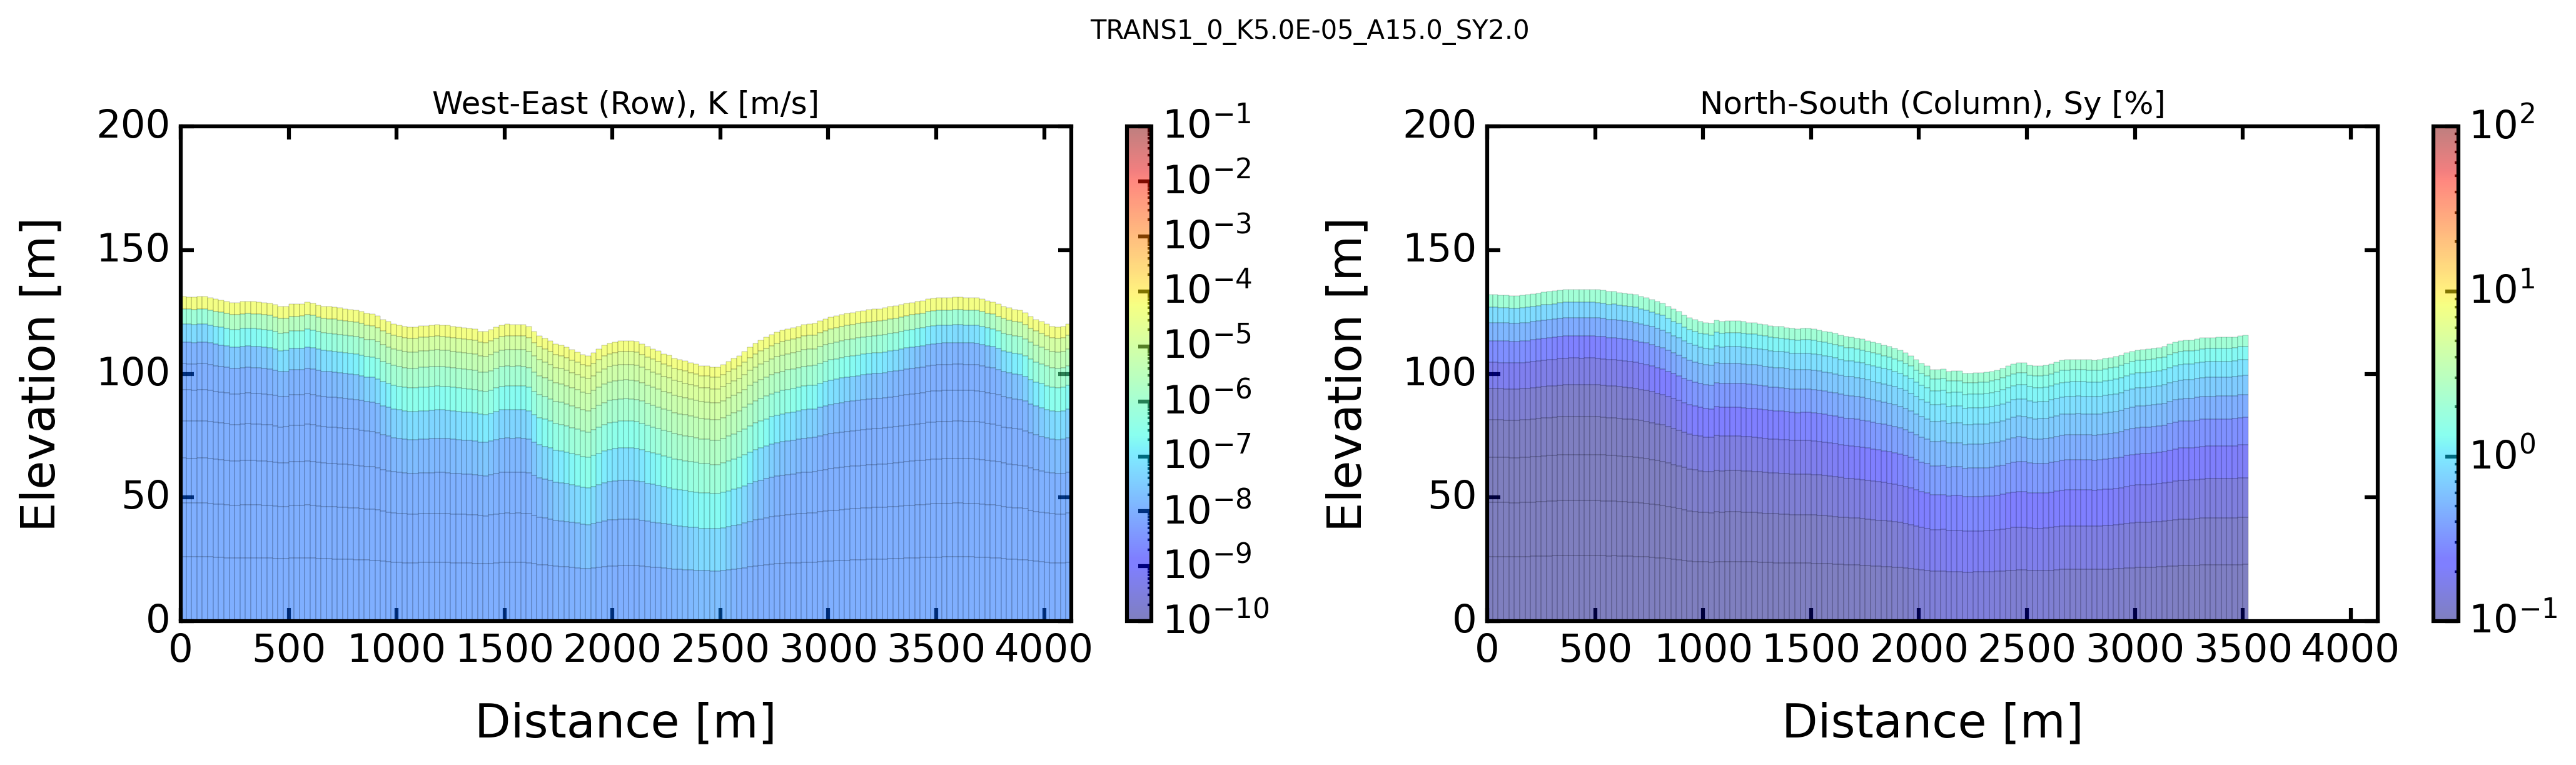

In [ ]:

BV = watershed_root.Watershed(watershed_name=watershed_name, dem_path=None, out_path=out_path, load=True)
area = BV.geographic.area

stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/' # necessary for plots
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/' # necessary for plots
calibration_folder = out_path+'/'+watershed_name+'/'+'results_calibration/' # necessary for plots

BV.calibration_folder = calibration_folder

box = True # or False
sink_fill = False # or True
# sim_state = 'steady' # 'steady' or 'transient'
sim_state = 'transient' # 'steady' or 'transient'
# first_clim = 'mean' # or 'first or value
plot_cross = True
cross_ylim = [0,150]
check_grid = True
dis_perlen = True
nlay = 10
lay_decay = 1.2 # 1 for no decay
verti_hk = None # or [ [1e-5, [0, 20]],
verti_sy = None
verti_ss = None
cond_drain = None # or value of conductance
sy = 1 / 100 # -
sy_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
hk_decay = 0
ss = 1e-5
ss_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL
zone_partic = 'domain' # or watershed
vka = 1
bottom = 0
thickness = 100
Klog_transf = False

# Recharge
BV.add_climatic()
recharge = R_mm_day_filt[:] / 1000
runoff = recharge * 0.1
first_clim = 'mean'
BV.climatic.update_first_clim(first_clim)
BV.climatic.update_recharge(recharge, sim_state=sim_state)
BV.climatic.update_runoff(runoff, sim_state=sim_state)

# Objects
BV.add_settings()
BV.add_hydraulic()
BV.add_oceanic(sea_level)

# Fixed
BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_sy(sy)
BV.hydraulic.update_sy_decay(sy_decay)
BV.hydraulic.update_ss(ss)
BV.hydraulic.update_ss_decay(ss_decay)
BV.hydraulic.update_vka(vka)
BV.hydraulic.update_hk_vertical(verti_hk) # here for lays [ [1e-5m/s, [0, 20m]]
BV.hydraulic.update_sy_vertical(verti_sy)
BV.hydraulic.update_ss_vertical(verti_ss)
BV.hydraulic.update_bottom(bottom)
BV.settings.update_dis_perlen(dis_perlen)
BV.settings.update_bc_sides(bc_left, bc_right)
BV.hydraulic.update_thick(thickness)

alpha = 15 # in m
n_factor = 2

the_K0 = 5e-5*24*3600
BV.hydraulic.update_hk(the_K0) # 3D
Kmin_for_hk_decay = 1e-8*24*3600
BV.hydraulic.update_hk_decay(1/alpha, min_value=Kmin_for_hk_decay, log_transf=Klog_transf, grad_elev=[93,136,-20]) # 0

# the_sy0 = 0.1/100 #
the_sy0 = 2/100 #
BV.hydraulic.update_sy(the_sy0)
Symin_for_sy_decay = 0.1/100
BV.hydraulic.update_sy_decay((1/alpha)/n_factor, min_value=Symin_for_sy_decay, log_transf=Klog_transf, grad_elev=[93,136,-20]) # 0
# BV.hydraulic.update_sy_decay(0) # 0

the_ss0 = 1e-10
BV.hydraulic.update_ss(the_ss0)
# Ssmin_for_ss_decay = 1e-10
# BV.hydraulic.update_ss_decay((1/alpha)/n_factor, min_value=Ssmin_for_ss_decay, log_transf=Klog_transf, grad_elev=[93,136,-20]) # 0
BV.hydraulic.update_ss_decay(0) # 0

compt = 0

# Change

model_name = f"{vers}_{compt}_K{the_K0/24/3600:.1e}_a{alpha:.1f}_Sy{the_sy0*100:.1f}"
print(model_name)

BV.settings.update_model_name(model_name)

BV.settings.update_check_model(plot_cross=plot_cross, check_grid=check_grid, cross_ylim=[0,200])

model_modflow = BV.preprocessing_modflow(for_calib=True) # BV.calibration_folder

list_model_name = []
list_model_name.append(model_name)
list_model_modflow = []
list_model_modflow.append(model_modflow)

dictio = {}
dictio['list_model_name'] = list_model_name
dictio['list_model_modflow'] = list_model_modflow
pickle_file = BV.calibration_folder+'/'+model_name+'/'+'results_'+model_name+'.pkl'
with open(pickle_file, 'wb') as f:
    pickle.dump(dictio, f)

success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True, link_mt3dms=True)

prob_cells = model_modflow.prob_cells

BV.postprocessing_modflow(model_modflow,
                          watertable_elevation = True,
                          seepage_areas = True,
                          outflow_drain = True,
                          accumulation_flux = True,
                          watertable_depth = True,
                          groundwater_flux = False,
                          groundwater_storage = False,
                          intermittency_weekly = True,
                          intermittency_yearly = False,
                          export_all_tif = False)

timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=None,
                                                  model_mt3dms=None,
                                                  datetime_format=True,
                                                  subbasin_results=True,
                                                  intermittency_weekly=True,
                                                  intermittency_yearly=False) # or None

iter_results = MatchingStreams(BV, iteration_label=model_name, from_calib=True)

# obs_to_sim = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obs_pt.shp'))
# obs_to_simf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obs_ptf.shp'))
# obsf_to_sim = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obsflow.shp'))
obsf_to_simf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','obsflowf.shp'))

# sim_to_obs = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','sim_pt.shp'))
# sim_to_obsf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','sim_ptf.shp'))
# simf_to_obs = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflow.shp'))
simf_to_obsf = gpd.read_file(os.path.join(BV.calibration_folder, model_name, '_matchingstreams','simflowf.shp'))

# mean_obs_to_sim = np.nanmean(obs_to_sim[obs_to_sim['VALUE1']>=0]['VALUE1'])
# mean_obs_to_simf = np.nanmean(obs_to_simf[obs_to_simf['VALUE1']>=0]['VALUE1'])
# mean_obsf_to_sim = np.nanmean(obsf_to_sim[obsf_to_sim['VALUE1']>=0]['VALUE1'])
mean_obsf_to_simf = np.nanmean(obsf_to_simf[obsf_to_simf['VALUE1']>=0]['VALUE1'])

# mean_sim_to_obs = np.nanmean(sim_to_obs[sim_to_obs['VALUE1']>=0]['VALUE1'])
# mean_sim_to_obsf = np.nanmean(sim_to_obsf[sim_to_obsf['VALUE1']>=0]['VALUE1'])
# mean_simf_to_obs = np.nanmean(simf_to_obs[simf_to_obs['VALUE1']>=0]['VALUE1'])
mean_simf_to_obsf = np.nanmean(simf_to_obsf[simf_to_obsf['VALUE1']>=0]['VALUE1'])

### vf simf/obsf - with : gap=0.5, streams : RNF, rec : 1000 (year) ==> isba
obs = mean_obsf_to_simf
sim = mean_simf_to_obsf
indicator = sim/obs



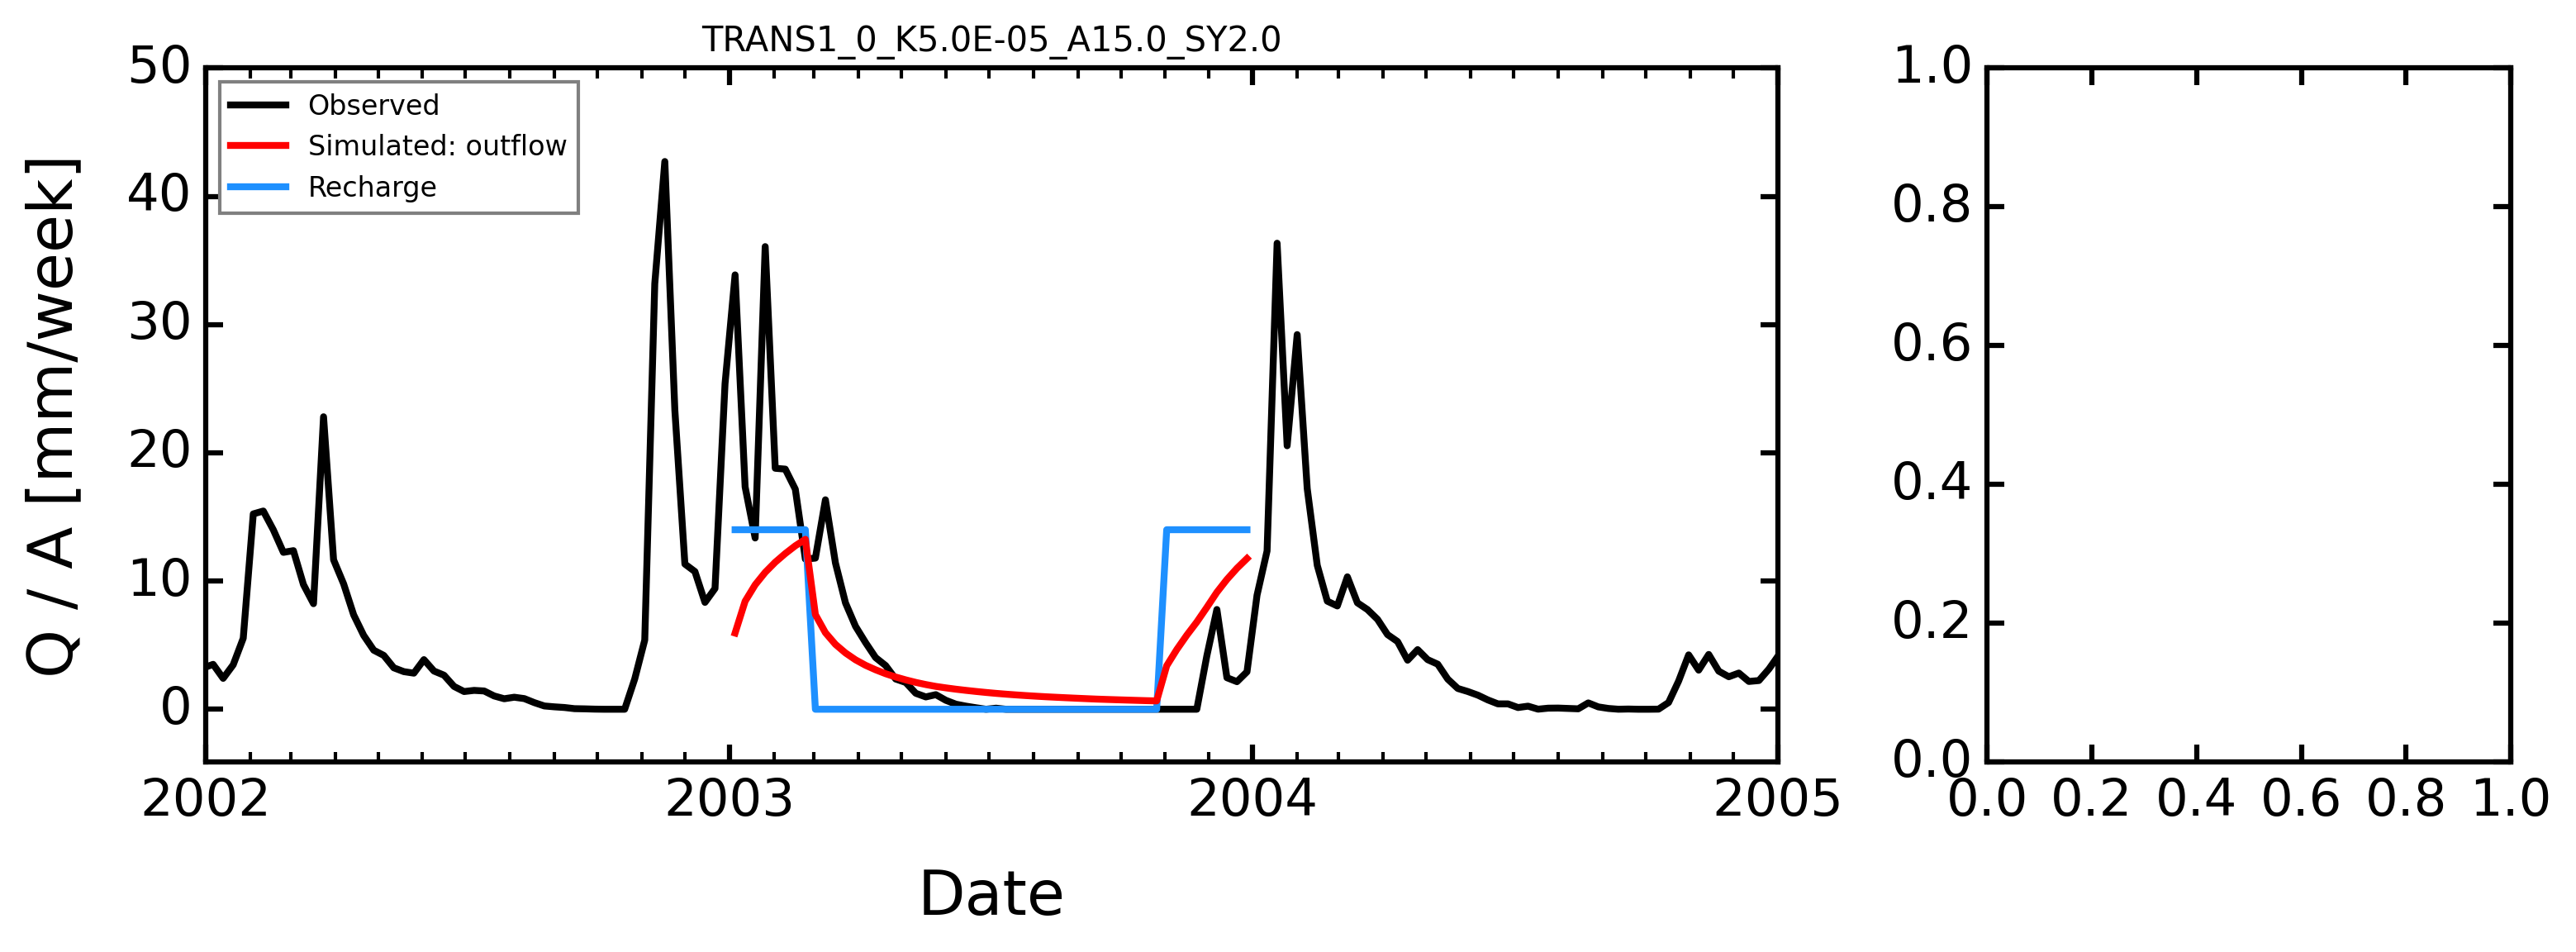

In [ ]:

area = int(round(BV.geographic.area))

Qobs_path = data_path + 'Debit_Exu_Kervidy_Aghrys_LJr_2024-04.txt'
Qobs = pd.read_csv(Qobs_path, sep=';', header=None)
date = pd.to_datetime(Qobs[0]+' '+Qobs[1], format="%d/%m/%Y %H:%M:%S")
Qobs.index = date
Qobs = Qobs[2].to_frame(name="Q")
Qobs = Qobs / 1000 # L/d to m3/d
Qobs = (Qobs / (area*1000000)) # m3/d to m/day
Qobs = Qobs.resample('W').mean()
# Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month
# Qobs = select_period(Qobs, 2003, 2003)
Qobs = Qobs * 7 * 1000

simul_list = sorted(glob.glob(os.path.join(calibration_folder,vers+'*')), key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):

    fig, (a0, a1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(12,3.5), dpi=300)

    model_name = os.path.split(simul)[-1]

    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)

    Rmod = Smod['recharge'] * 7 * 1000
    rmod = Smod['runoff'] * 7 * 1000

    Omod = (Smod['outflow_drain'] * 7 * 1000)
    Qmod = Omod + rmod

    ax = a0
    ax.plot(Qobs, color='k', lw=2, ls='-', zorder=0, label='Observed')
    # ax.fill_between(Omod.index, Omod, Qmod, color='red', lw=1, label='Simualted : outflow + runoff', alpha=0.5)
    # ax.plot(Omod, color='red', lw=2, label='Simulated: outflow')
    ax.plot(Qmod, color='red', lw=2, label='Simulated: outflow')
    ax.plot(Rmod, color='dodgerblue', lw=2, ls='-', zorder=0, label='Recharge')
    ax.set_xlabel('Date')
    ax.set_ylabel('Q / A [mm/week]')
    # ax.set_yscale('log')
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.to_datetime('2002'), pd.to_datetime('2005'))
    ax.legend(loc='upper left')
    ax.set_title(model_name.upper(), fontsize=10)
    ax.set_ylim(None,50)

    # axb = ax.twinx()
    # axb.bar(Rmod.index, Rmod, color='dodgerblue', width=10, edgecolor='None', lw=0, alpha=1, label='Recharge')
    # axb.set_ylim(0,100)
    # axb.invert_yaxis()
    # axb.set_yticklabels([0,100])
    # axb.legend(loc='upper right')

    """
    Qobs_stat = select_period(Qobs,2003,2003)
    Qmod_stat = select_period(Qmod,2003,2003)

    # import hydroeval as he
    # NSE = he.evaluator(he.nse, Qmod_stat, Qobs_stat)[0]
    # NSElog = he.evaluator(he.nse, Qmod_stat, Qobs_stat, transform='log')[0]
    # RMSE = np.sqrt(np.nanmean((Qobs_stat.values-Qmod_stat.values)**2))
    # KGE = he.evaluator(he.kge, Qmod_stat, Qobs_stat)[0][0]
    # print(model_name.upper())
    # print('NSE',round(NSE,2))
    # print('NSElog',round(NSElog,2))
    # print('RMSE',round(RMSE,2))
    # print('KGE',round(KGE,2))

    ax = a1
    ax.scatter(Qobs_stat, Qmod_stat, s=25, edgecolor='none', alpha=0.75, facecolor='forestgreen')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.plot((0.1,1000),(0.1,1000), color='grey', zorder=-1)
    ax.set_xlim(1,500)
    ax.set_ylim(1,500)
    ax.set_xlim(0.1,300)
    ax.set_ylim(0.1,300)

    ax.set_xlabel('$Q_{obs}$ / A [mm/week]', fontsize=12)
    ax.set_ylabel('$Q_{sim}$ / A [mm/week]', fontsize=12)

    fig.tight_layout()
    """



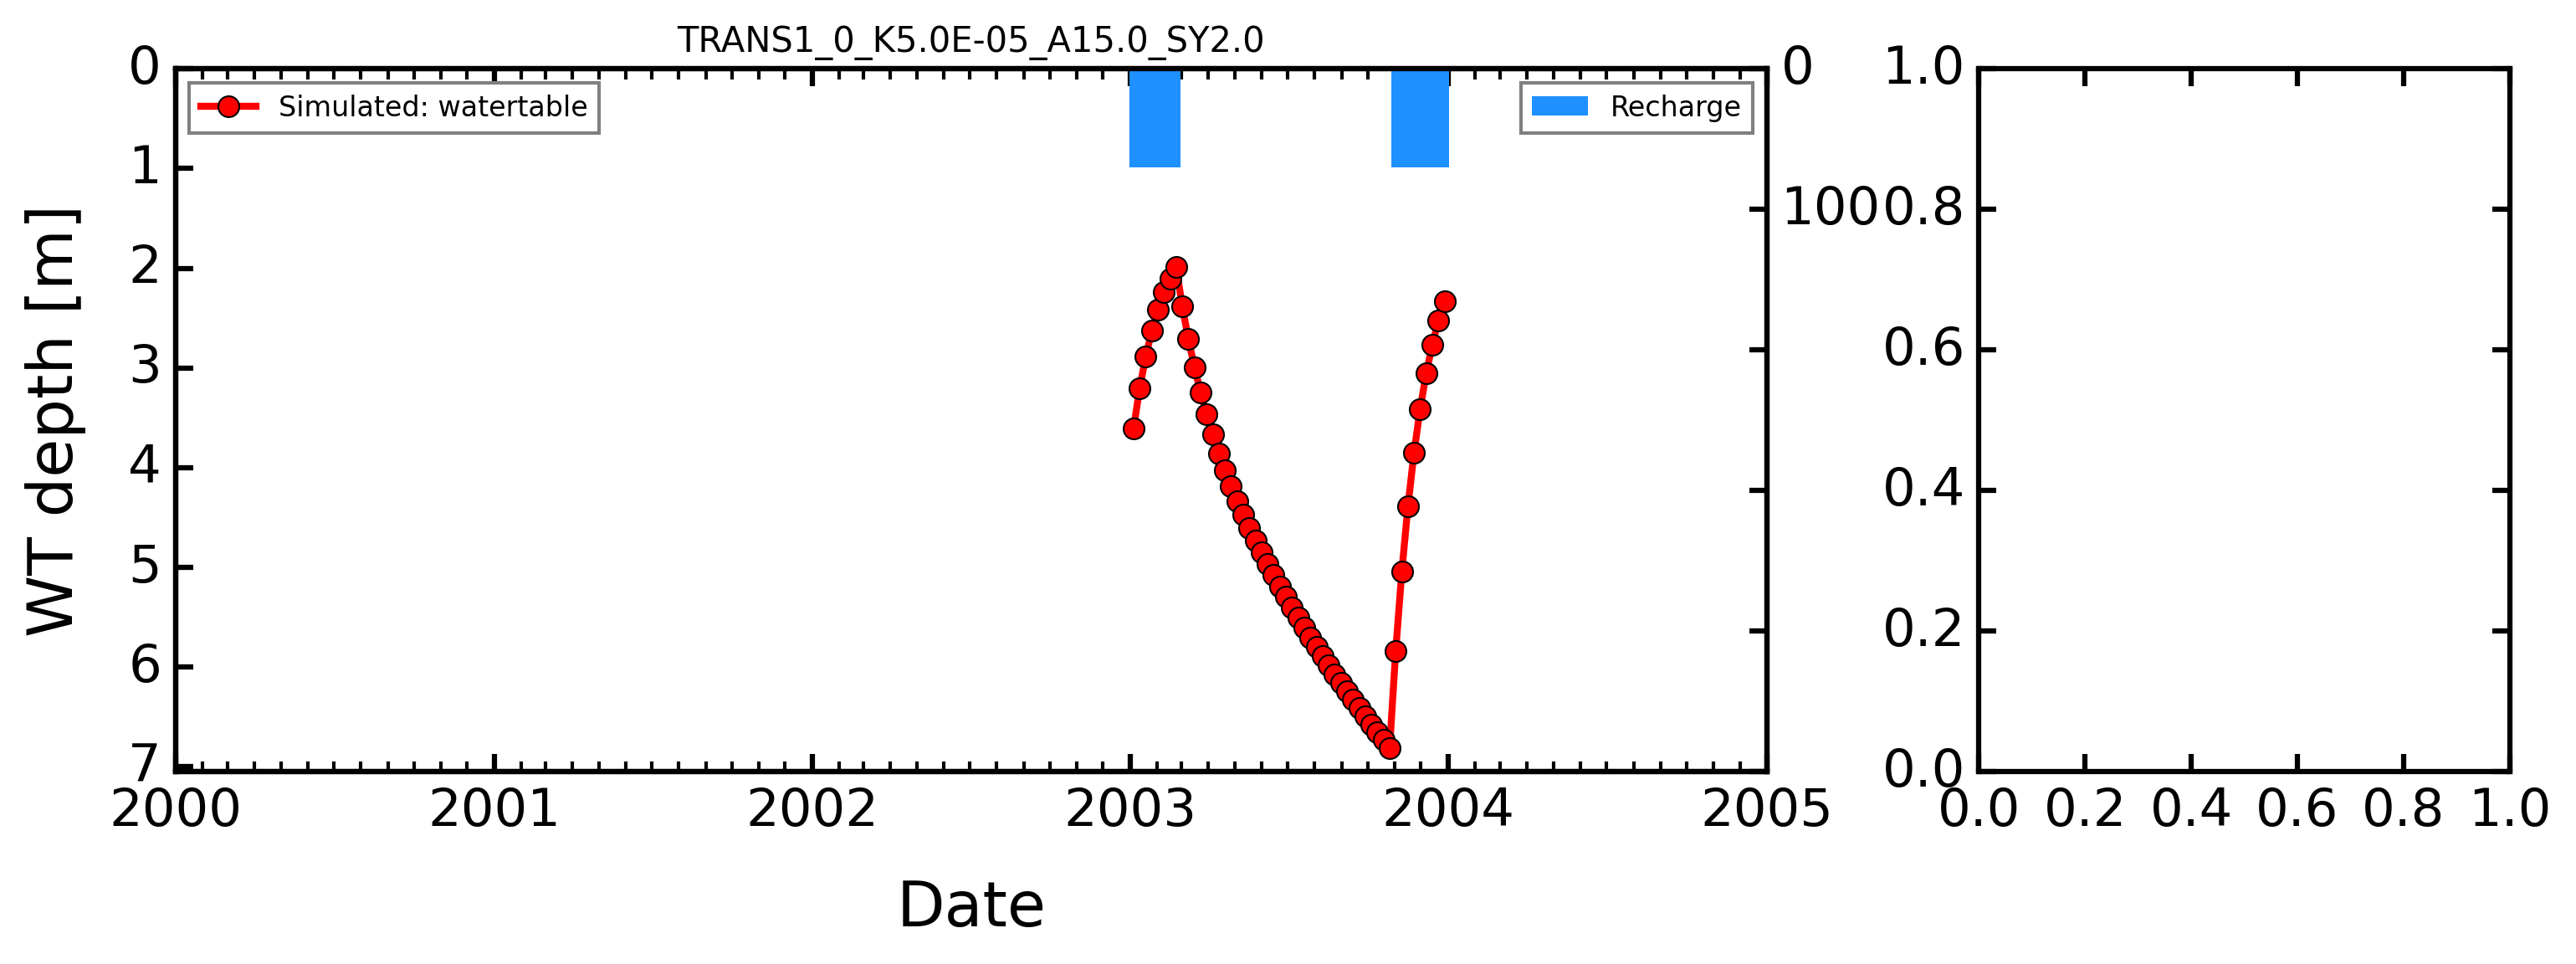

In [ ]:

area = int(round(BV.geographic.area))

# Qobs_path = data_path + 'Debit_Exu_Kervidy_Aghrys_LJr_2024-04.txt'
# Qobs = pd.read_csv(Qobs_path, sep=';', header=None)
# date = pd.to_datetime(Qobs[0]+' '+Qobs[1], format="%d/%m/%Y %H:%M:%S")
# Qobs.index = date
# Qobs = Qobs[2].to_frame(name="Q")
# Qobs = Qobs / 1000 # L/d to m3/d
# Qobs = (Qobs / (area*1000000)) # m3/d to m/day
# Qobs = Qobs.resample('W').mean()
# # Qobs = Qobs.resample('M').sum() * 1000 # m/day to mm/month
# # Qobs = select_period(Qobs, 2003, 2003)
# Qobs = Qobs * 7 * 1000

simul_list = sorted(glob.glob(os.path.join(calibration_folder,vers+'*')), key=os.path.getmtime)

for i, simul in enumerate(simul_list[:]):


    model_name = os.path.split(simul)[-1]

    Smod_path = os.path.join(simul, r'_postprocess/_timeseries/_simulated_timeseries.csv')
    Smod = pd.read_csv(Smod_path, sep=';', index_col=0, parse_dates=True)

    Rmod = Smod['recharge'] * 7 * 1000

    WTEmod = Smod['watertable_elevation']
    WTDmod = Smod['watertable_depth']

    fig, (a0, a1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [3, 1]}, figsize=(12,3.5), dpi=300)

    ax = a0
    # ax.plot(Qobs, color='k', lw=2, ls='-', zorder=0, label='Observed')
    # ax.fill_between(Omod.index, Omod, Qmod, color='red', lw=1, label='Simualted : outflow + runoff', alpha=0.5)
    ax.plot(WTDmod, marker='o', color='red', lw=2, label='Simulated: watertable')
    # ax.plot(Rmod, color='dodgerblue', lw=2, ls='-', zorder=0, label='Recharge')
    ax.set_xlabel('Date')
    ax.set_ylabel('WT depth [m]')
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(pd.to_datetime('2000'), pd.to_datetime('2005'))
    ax.legend(loc='upper left')
    ax.set_title(model_name.upper(), fontsize=10)
    ax.set_ylim(0,None)
    ax.invert_yaxis()

    axb = ax.twinx()
    axb.bar(Rmod.index, Rmod, color='dodgerblue', width=10, edgecolor='None', lw=0, alpha=1, label='Recharge')
    axb.set_ylim(0,100)
    axb.invert_yaxis()
    axb.set_yticklabels([0,100])
    axb.legend(loc='upper right')



In [ ]:

list_folder = glob.glob(BV.calibration_folder+'/'+vers+'*')

model_name = list_folder[0].split(os.path.sep)[-1]

pickle_file = list_folder[0] + '/' + 'results_' + model_name + '.pkl'
with open(pickle_file, 'rb') as f:
    d = pickle.load(f)

list_model_name = d['list_model_name'][:]
list_flow_model = d['list_model_modflow'][:]

model_modflow = list_flow_model[0]

# Prepare particle tracking from seepage inside the catchment studied
tif_seep = os.path.join(BV.calibration_folder, model_name, '_postprocess/_rasters','seepage_areas_t(0).tif')
tif_seep_clip = os.path.join(BV.calibration_folder, model_name, '_postprocess/_rasters','seepage_areas_t(0)_clip.tif')
wbt.clip_raster_to_polygon(
    tif_seep,
    BV.stable_folder + '/geographic/watershed.shp',
    tif_seep_clip,
    maintain_dimensions=True)

BV.add_settings()
BV.settings.update_input_particles(
                                # zone_partic = tif_file_clip,
                                # zone_partic = BV.geographic.watershed_box_buff_dem,
                                zone_partic = tif_seep_clip,
                                cell_div = 1, # 1
                                zloc_div = False,  # or False, add cells at cell bottom
                                bore_depth = None, # '[0,5,10] for 3 particles or None
                                track_dir = 'backward',
                                # track_dir = 'forward', # backward
                                sel_random = None, # or int
                                sel_slice = None, # or int
                                )

model_modpath = BV.preprocessing_modpath(model_modflow, for_calib=True)
success_modpath = BV.processing_modpath(model_modpath, write_model=True, run_model=True)

BV.postprocessing_modpath(model_modpath,
                      ending_point=True,
                      starting_point=True,
                      pathlines_shp=True,
                      particles_shp=True,
                      random_id=None, # select randomly to save (for pathlines and particles)
                      ) # None

BV.filtprocessing_modpath(model_modpath,
                      norm_flux=True, # for forward only
                      filt_time=True, # delete particles with time at 0, add a column with time divided by 365 (considering recharge in days)
                      filt_seep=True, # only forward, keep only particles finishing in zone1 (seepage), keep only particles finishing in k1 (first layer)
                      filt_inout=True, # delete particles in and out in the same cell (first layer)
                      calc_rtd=False, # compute residence time distribution
                      random_id=None, # select randomly to keep
                      ) # None



[INFO] Initializing settings module for groundwater parameters


writing loc particle data
FloPy is using the following executable to run the model: ../../../../../bin/linux/mp6
Processing basic data ...
Checking head file ...
Checking budget file and building index ...
 
Run particle tracking simulation ...
Processing Time Step     1 Period     1.  Time =  1.00000E+00                                                                       
Particle tracking complete. Writing endpoint file ...                                                                               
End of MODPATH simulation. Normal termination.
(numpy.record, [('particleid', '<i4'), ('particlegroup', '<i4'), ('timepointindex', '<i4'), ('cumulativetimestep', '<i4'), ('time', '<f4'), ('x', '<f4'), ('y', '<f4'), ('z', '<f4'), ('k', '<i4'), ('i', '<i4'), ('j', '<i4'), ('grid', '<i4'), ('xloc', '<f4'), ('yloc', '<f4'), ('zloc', '<f4'), ('linesegmentindex', '<i4')])
(numpy.record, [('particleid', '<i4'), ('particlegroup', '<i4'), ('timepointindex', '<i4'), ('cumulativetimestep', '<i4'

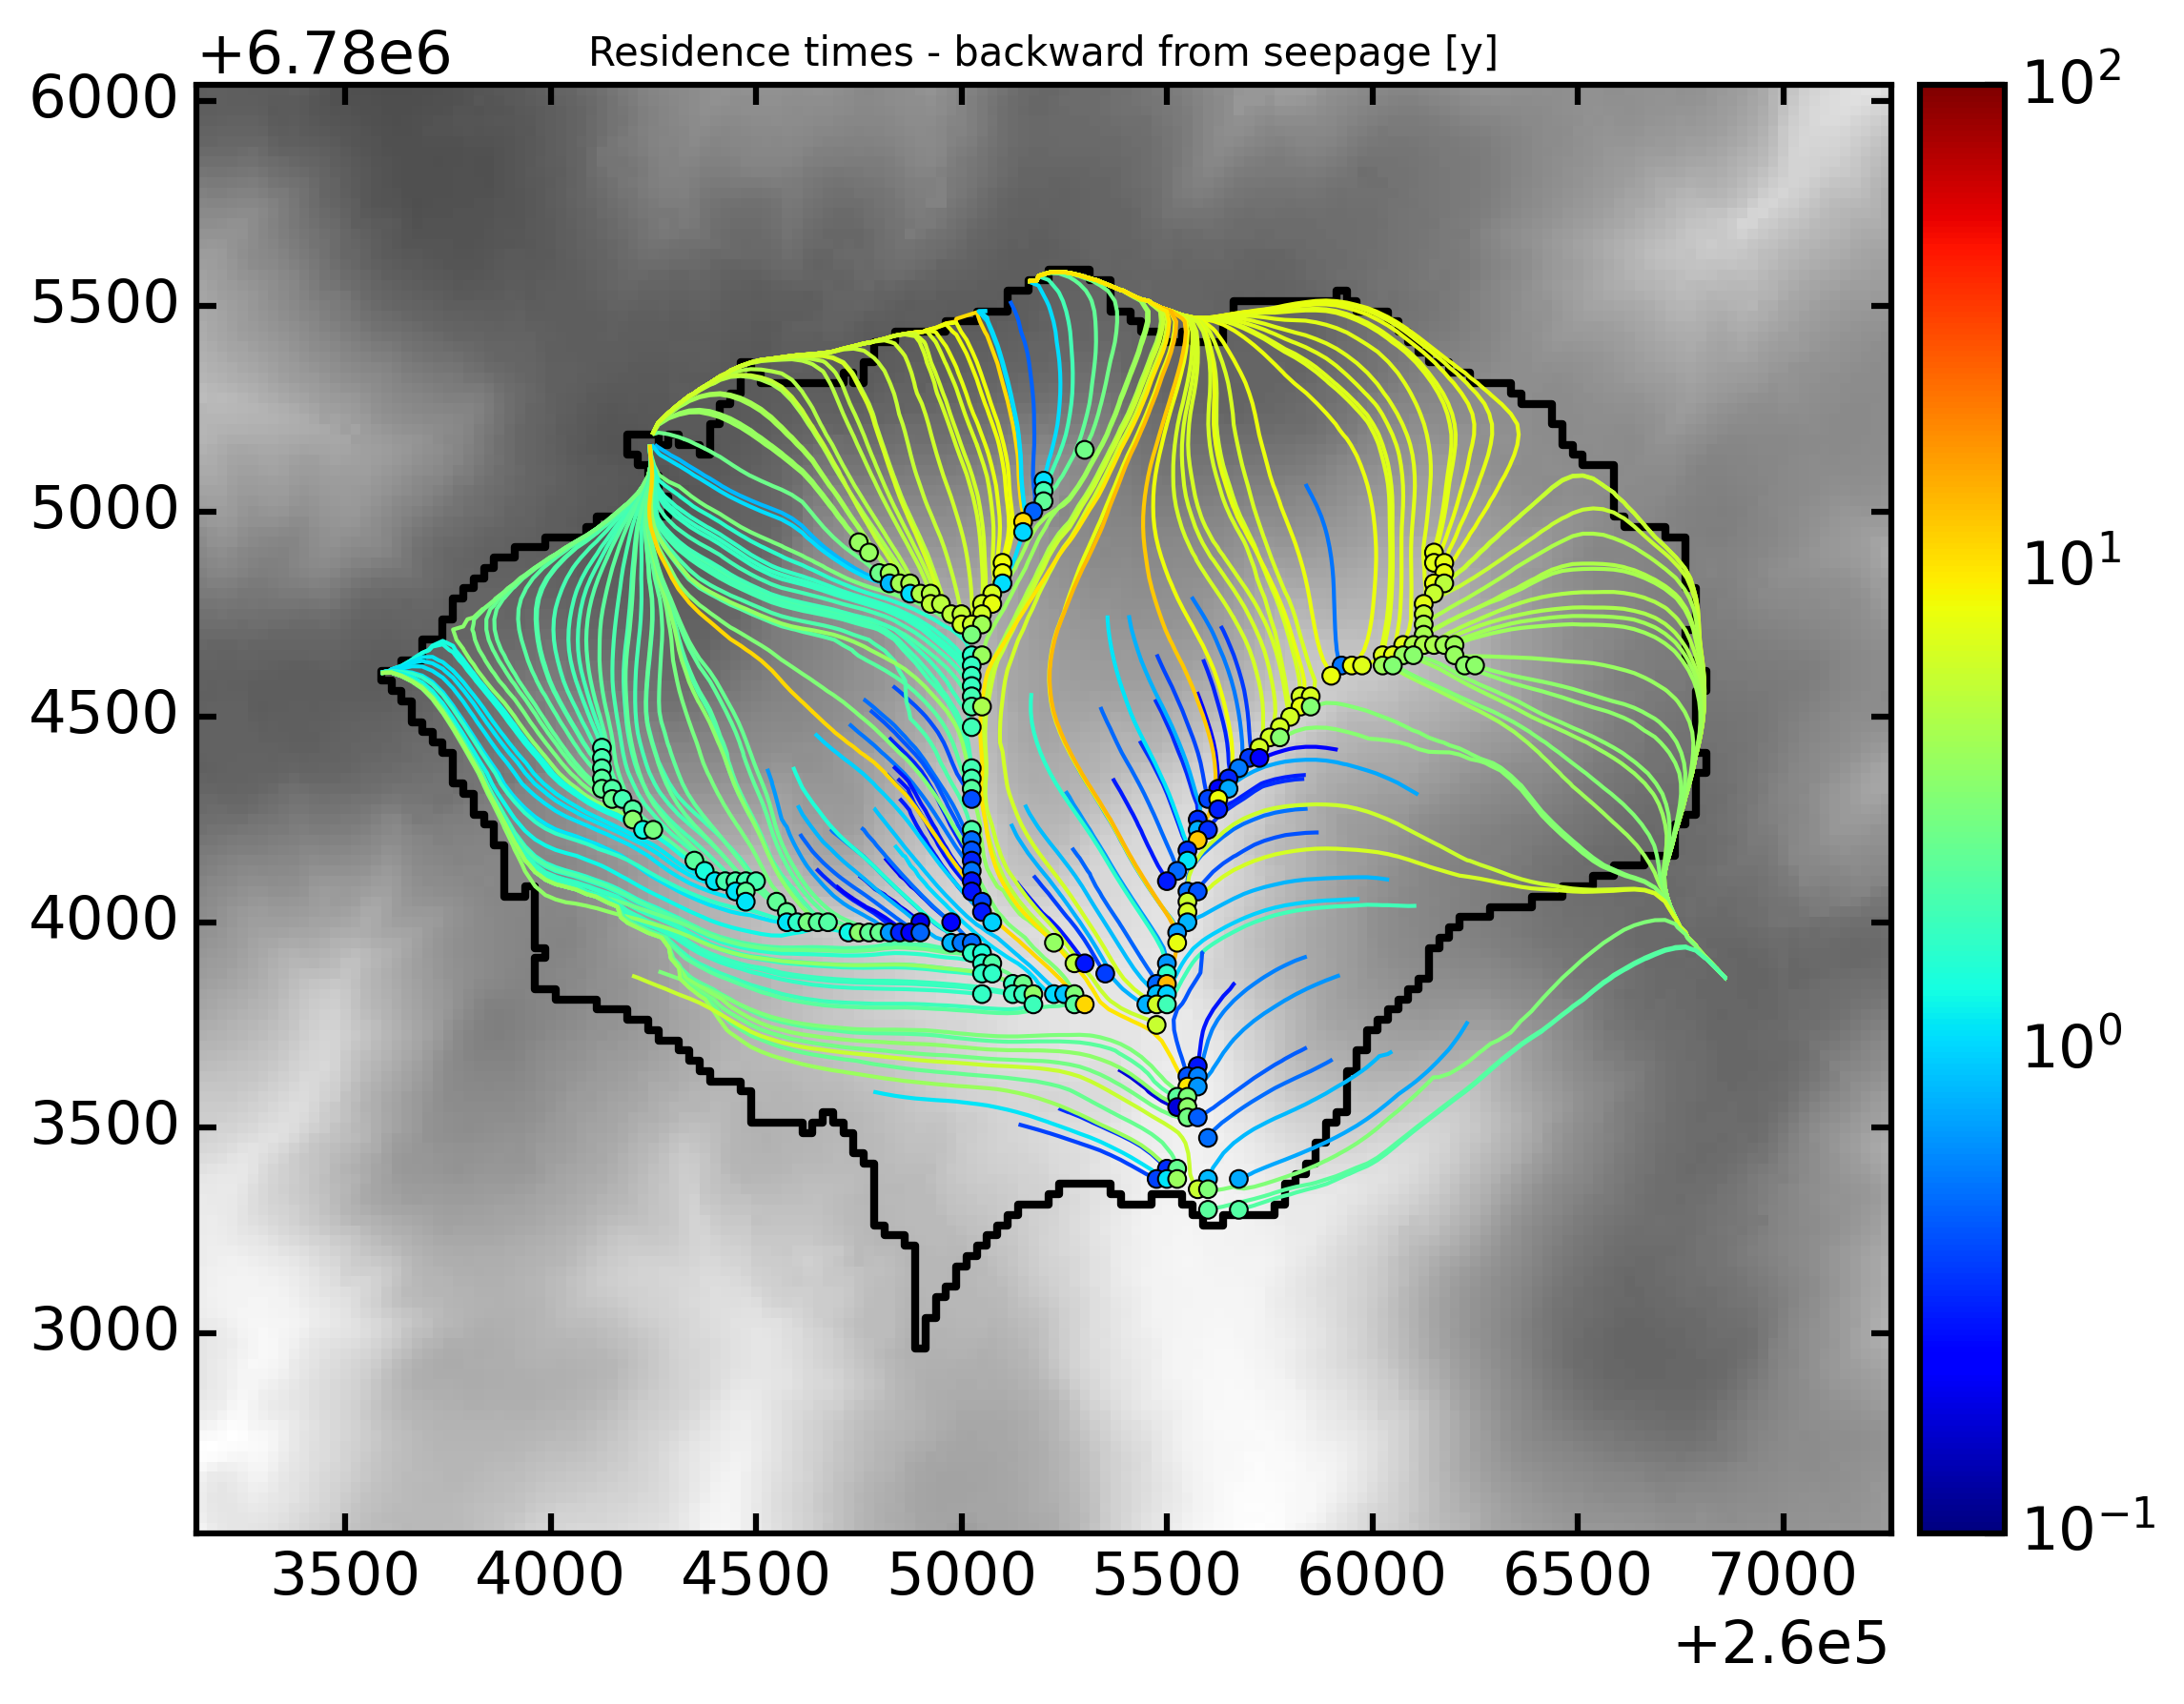

In [ ]:

shp_pathlines = gpd.read_file(calibration_folder+model_name+'/_postprocess/_particles/pathlines_weighted.shp')
shp_endpoints = gpd.read_file(calibration_folder+model_name+'/_postprocess/_particles/starting_weighted.shp')

line = gpd.read_file(stable_folder+'geographic/'+'watershed.shp')

dem_rio = rasterio.open(BV.geographic.watershed_box_buff_dem)
dem_data = dem_rio.read(1)
dem_data = np.ma.masked_where(dem_data < 0, dem_data)

norm = mcolors.LogNorm(vmin=0.1, vmax=100)
im = cm.ScalarMappable(cmap='jet', norm=norm)
im.set_array([])

fig, ax = plt.subplots(1,1, figsize=(8,6))

# Base raster and layers
rasterio.plot.show(dem_data, ax=ax, transform=dem_rio.transform,
                   cmap='Greys', alpha=0.7, zorder=-10)

shp_pathlines.plot(ax=ax, column='time_win_y', cmap='jet', lw=1,
                   norm=norm, zorder=1)

shp_endpoints.plot(ax=ax, column='time_win_y', cmap='jet', lw=0.5, markersize=20,
                        legend=False, norm=norm, zorder=2, edgecolor='k')

line.plot(ax=ax, facecolor='None', edgecolor='k', lw=2, zorder=-1)

# Title
ax.set_title('Residence times - backward from seepage [y]', fontsize=10)

# Colorbar on the right, same height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(im, cax=cax, orientation='vertical')

fig.tight_layout()

# fig.savefig(os.path.join(simulations_folder, model_name,
#                             '_postprocess', '_figures', 'RTD_'+model_name+'.png'))



In [17]:

list_folder = glob.glob(BV.calibration_folder+'/'+vers+'*')

model_name = list_folder[0].split(os.path.sep)[-1]

pickle_file = list_folder[0] + '/' + 'results_' + model_name + '.pkl'
with open(pickle_file, 'rb') as f:
    d = pickle.load(f)

list_model_name = d['list_model_name'][:]
list_flow_model = d['list_model_modflow'][:]

model_modflow = list_flow_model[0]

BV.add_transport()

nper = model_modflow.nper
nlay = model_modflow.mf.nlay
nrow = model_modflow.mf.nrow
ncol = model_modflow.mf.ncol

sconc_init = np.ones((nlay, nrow, ncol)) * (100/1000) # 50 mg/L en kg/m3
sconc_input = {i: np.ones((nrow, ncol)) * (50/1000) for i in range(nper)}
sconc_input = dict(islice(sconc_input.items(), 1, None))
rate_decay = np.ones((nlay, nrow, ncol)) * (1/(2*365))

BV.transport.update_mt3dms_parameters(
                 spc_name='NO3',
                 sconc_init=sconc_init,          # array of (nlay, nrow, ncol)
                 sconc_input=sconc_input,         # dictionnray [time] with array of (nlay, nrow, ncol)
                 disp_long=5,           # float, longitudinal dispersitvity in meters
                 disp_transh=0.5,         # float, ratio of the horizontal transverse dispersivity to disp_long, usually 0.1*disp_long
                 disp_transv=0.05,         # float, ratio of the vertical transverse dispersivity to disp_long, usually 0.01*disp_long
                 diffu_coeff=1e-10*3600*24,         # molecular diffusion in (L2T-1)
                 react_order=1,      # None: no-reaction, 0: zero-order, 1: first-order
                 rate_decay=rate_decay,          # array of (nlay, nrow, ncol), unit T-1
                 plot_conc=True)

scenario = 's1'
model_mt3dms = BV.preprocessing_mt3dms(model_modflow, for_calib=True, suffix_name='_mt_'+scenario)
success_mt3dms = BV.processing_mt3dms(model_mt3dms, write_model=True, run_model=True, verbose=True)

pp_model = BV.postprocessing_mt3dms(model_mt3dms,
                          concentration_seepage=True,
                          mass_seepage=True,
                          mass_accumulated=True,
                          export_all_tif=True) # None

timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=model_modpath,
                                                  model_mt3dms=model_mt3dms,
                                                  suffix_name=scenario,
                                                  datetime_format=True,
                                                  subbasin_results=True,
                                                  intermittency_weekly=True,
                                                  residence_times=True,
                                                  concentration_seepage=True,
                                                  mass_accumulated=True
                                                  ) # or None



[INFO] Initializing transport module for concentration parameters


FloPy is using the following executable to run the model: ../../../../../bin/linux/mt3dusgs

 MT3D-USGS - Modular 3D Multi-Species Transport Model [Ver 1.1.0]   
 and based on MT3DMS. MT3D-USGS developed in cooperation by 
 S.S. Papadopulos & Associates and the U.S. Geological Survey

 Using NAME File: TRANS1_0_K5.0e-05_a15.0_Sy2.0_mt_s1.mtnam

 STRESS PERIOD NO.    1

 TIME STEP NO.    1
 FROM TIME =   0.0000     TO    1.0000    

 Transport Step:    1   Step Size:  0.1613     Total Elapsed Time:  0.16125    
 Outer Iter.  1  Inner Iter.  1:  Max. DC =  0.4629      [K,I,J]    1  140  129
 Outer Iter.  1  Inner Iter.  2:  Max. DC =  0.5863E-03  [K,I,J]    1   76   13
 Outer Iter.  1  Inner Iter.  3:  Max. DC =  0.2980E-05  [K,I,J]    1   76   13
 Outer Iter.  2  Inner Iter.  1:  Max. DC =  0.1005E-01  [K,I,J]    2  132    4
 Outer Iter.  2  Inner Iter.  2:  Max. DC =  0.1824E-04  [K,I,J]    1  133    4
 Outer Iter.  2  Inner Iter.  3:  Max. DC =  0.5960E-07  [K,I,J]    1  140  130
 Out

[INFO] Processing MT3DMS timestep 1/52


 Outer Iter.  3  Inner Iter.  1:  Max. DC =   0.000      [K,I,J]    1    1    1

 Program completed.   Total CPU time:  005 minutes 58.099 seconds


[INFO] Processing MT3DMS timestep 2/52
[INFO] Processing MT3DMS timestep 3/52
[INFO] Processing MT3DMS timestep 4/52
[INFO] Processing MT3DMS timestep 5/52
[INFO] Processing MT3DMS timestep 6/52
[INFO] Processing MT3DMS timestep 7/52
[INFO] Processing MT3DMS timestep 8/52
[INFO] Processing MT3DMS timestep 9/52
[INFO] Processing MT3DMS timestep 10/52
[INFO] Processing MT3DMS timestep 11/52
[INFO] Processing MT3DMS timestep 12/52
[INFO] Processing MT3DMS timestep 13/52
[INFO] Processing MT3DMS timestep 14/52
[INFO] Processing MT3DMS timestep 15/52
[INFO] Processing MT3DMS timestep 16/52
[INFO] Processing MT3DMS timestep 17/52
[INFO] Processing MT3DMS timestep 18/52
[INFO] Processing MT3DMS timestep 19/52
[INFO] Processing MT3DMS timestep 20/52
[INFO] Processing MT3DMS timestep 21/52
[INFO] Processing MT3DMS timestep 22/52
[INFO] Processing MT3DMS timestep 23/52
[INFO] Processing MT3DMS timestep 24/52
[INFO] Processing MT3DMS timestep 25/52
[INFO] Processing MT3DMS timestep 26/52
[INFO] P

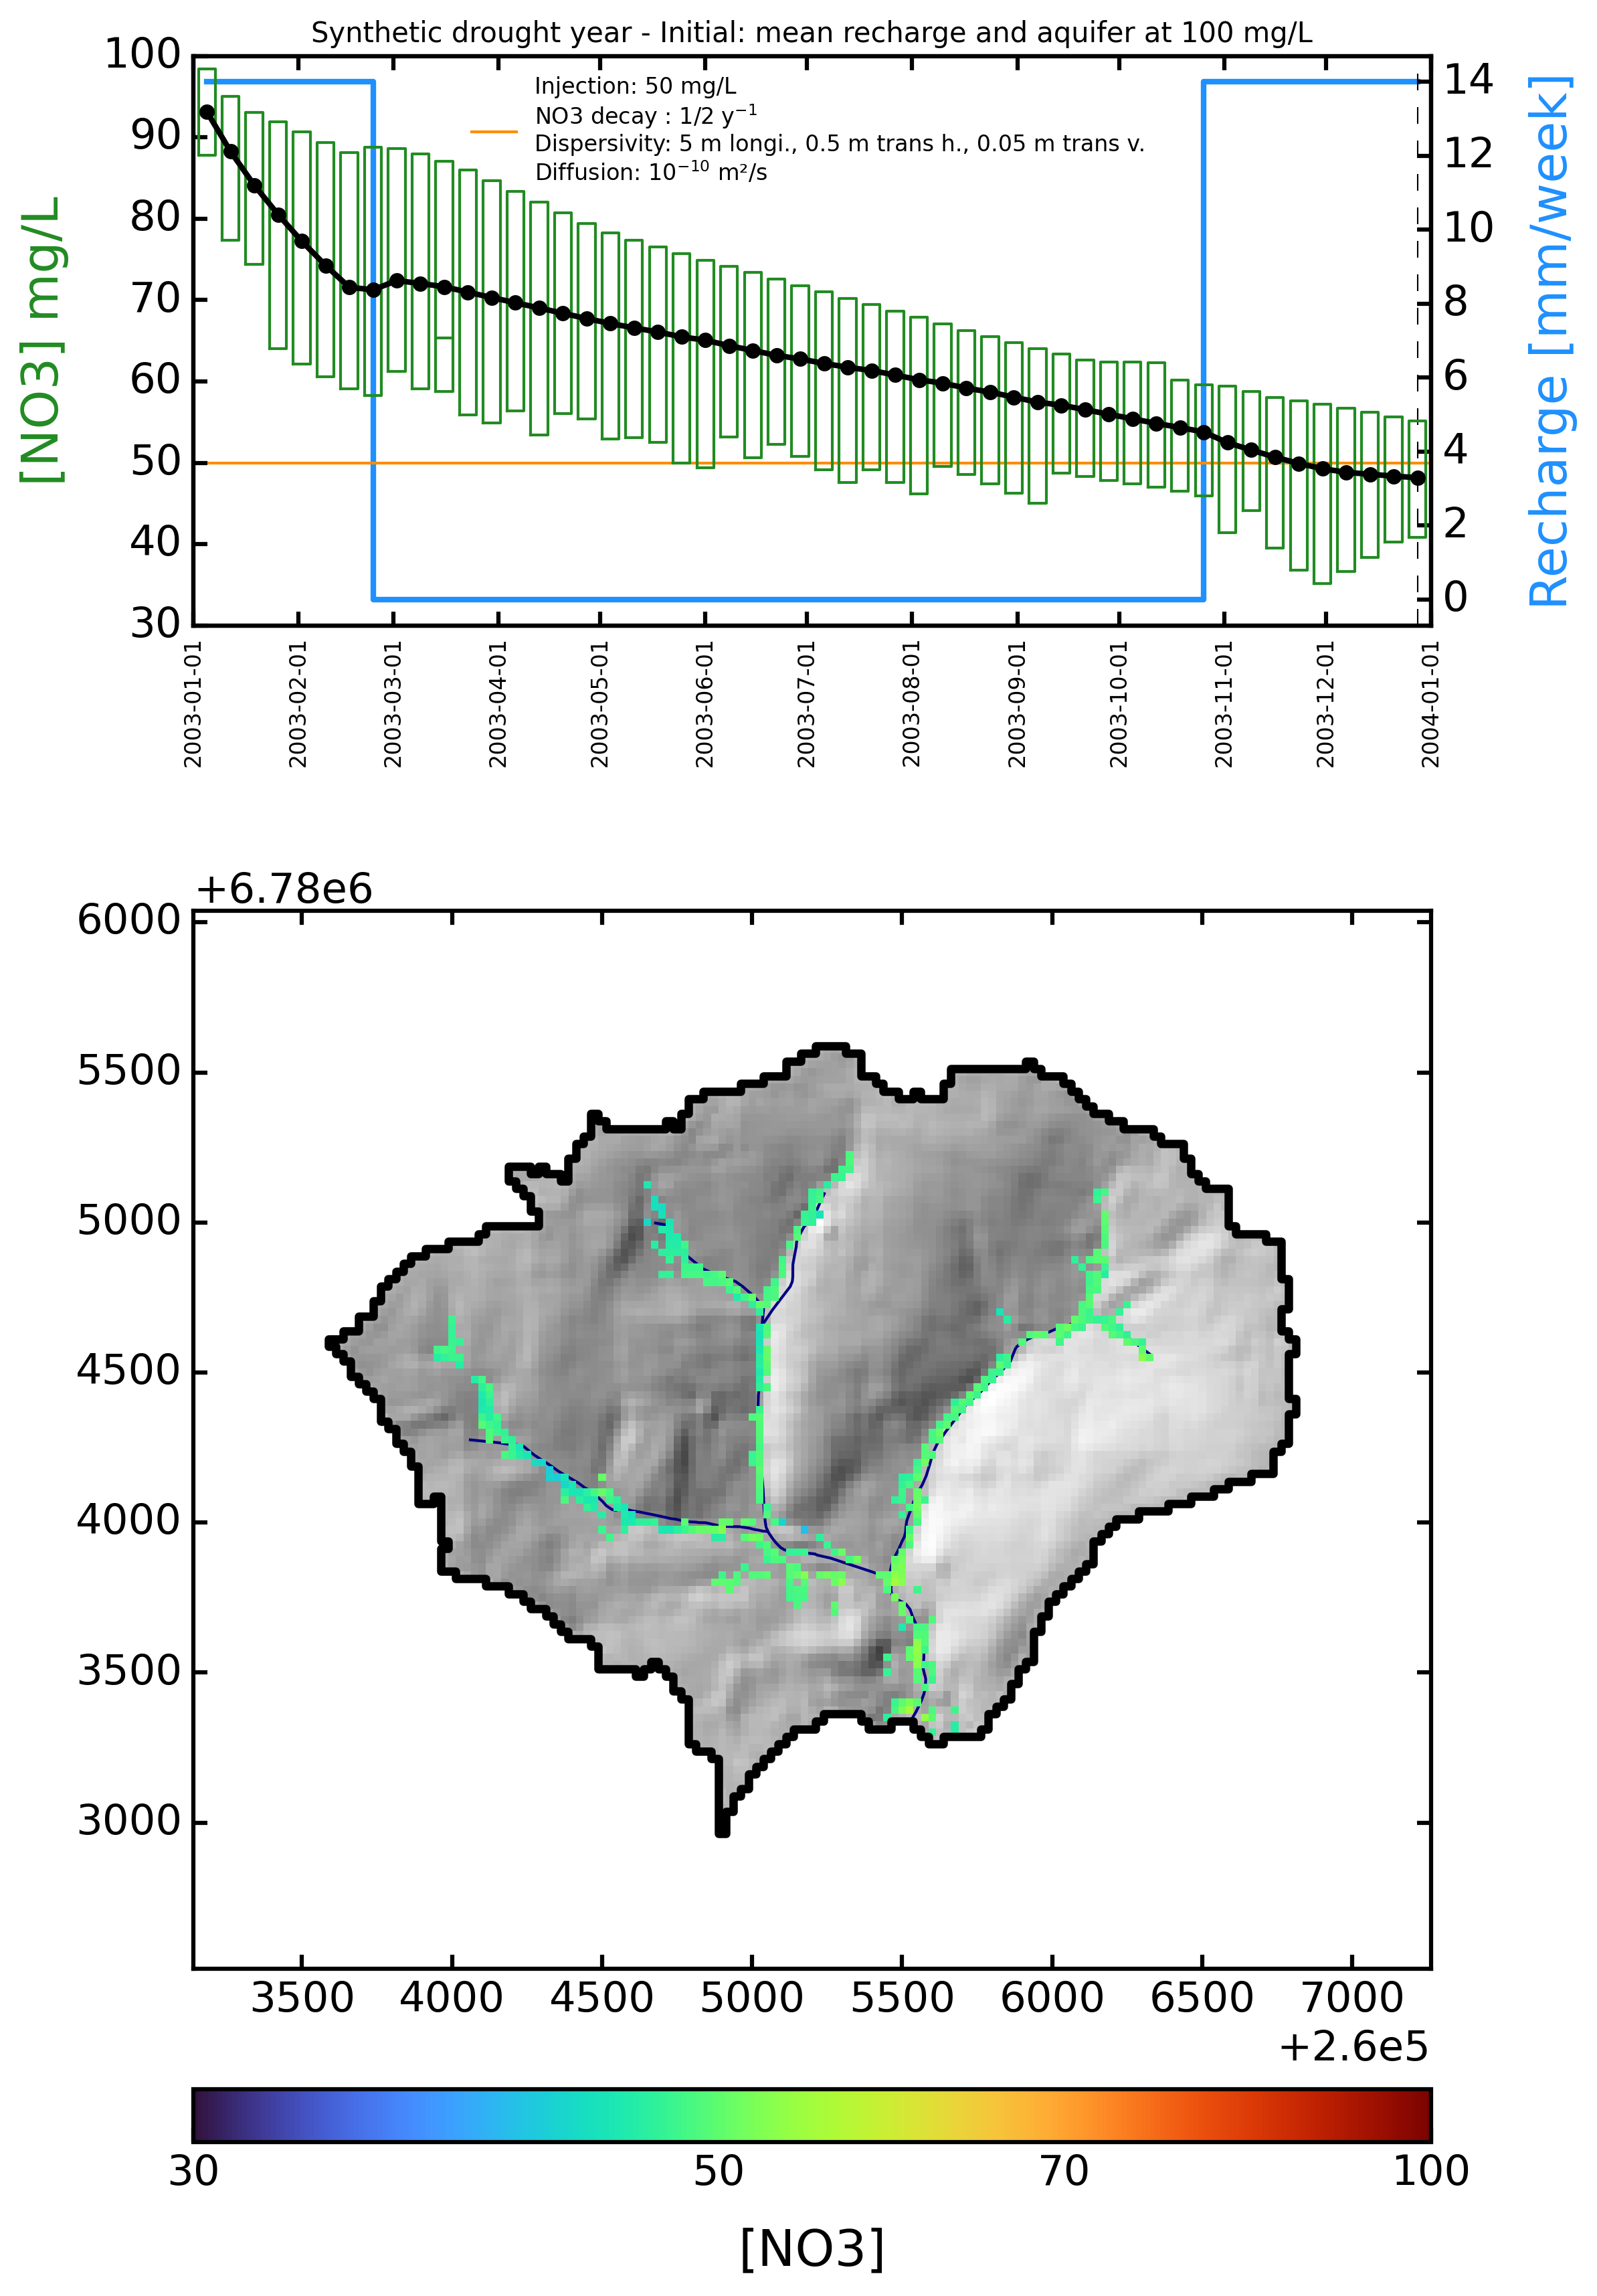

In [18]:

# Créer le GIF à la fin du processus
vgif_name = vers
gif_name = vgif_name+'.gif'

plot_gif = True

input_no3 = model_mt3dms.sconc_input[1].mean() * 1000

### USEFUL LINKS
# https://www2.hawaii.edu/~jonghyun/classes/S18/CEE696/files/11_flopy_mt3dms_transport_modeling.pdf
# https://download.feflow.com/html/help72/feflow/09_Parameters/Auxiliary_Data/peclet_number.html
# https://flopy.readthedocs.io/en/3.4.2/Notebooks/mt3dms_examples.html#

ucnobj  = bf.UcnFile(model_modflow.full_path + '/' + model_mt3dms.model_name_mt+'.UCN')
concobj_1c = ucnobj.get_alldata(mflay=None) # 4D:[time, lay, row, col]

concobj_1c_fil = concobj_1c.copy() * 1000
concobj_1c_fil[concobj_1c_fil>=1e30] = np.nan
concobj_1c_fil = concobj_1c_fil[:]

concobj_1c_fil_surf = {}

the_mins = []
the_maxs = []

# Boucle sur chaque pas de temps
# for i in range(len(concobj_1c_fil)):
for i in range((model_mt3dms.model_modflow.nper)):
    the_time = i
    # print(i)
    # try:
    seep = imageio.imread(os.path.join(model_modflow.full_path, f'_postprocess/_rasters/outflow_drain_t({int(the_time)}).tif'))
    # except:
    #     continue
    concobj_1c_fil_surf[the_time] = concobj_1c_fil[the_time+1][0]
    concobj_1c_fil_surf[the_time] = np.ma.masked_where(seep <= 0, concobj_1c_fil_surf[the_time])
    # concobj_1c_fil[the_time][0][concobj_1c_fil[the_time][0] <= 0] = np.nan

    the_mins.append(np.nanmin(concobj_1c_fil_surf[the_time]))
    the_maxs.append(np.nanmax(concobj_1c_fil_surf[the_time]))

the_min = np.nanmin(the_mins)
the_max = np.nanmax(the_maxs)

concobj_1c_fil_surf = dict(list(concobj_1c_fil_surf.items())[:])

# Liste pour accumuler les boxplots précédents
all_box_stats = []

# Définir le répertoire de sauvegarde des images
figures_dir = calibration_folder + '_figures/'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

mean_vals = []
mean_times = []

wbt.hillshade(stable_folder+'/geographic/watershed_dem.tif', stable_folder+'/geographic/watershed_hill.tif')

dem = rasterio.open(stable_folder+'/geographic/watershed_dem.tif')
hill = rasterio.open(stable_folder+'/geographic/watershed_hill.tif')

# Boucle sur chaque pas de temps
for i in range(len(concobj_1c_fil_surf)):
    the_time = i

    conc_plt = concobj_1c_fil_surf[i]

    xi = conc_plt.flatten()
    xi = xi[~np.isnan(xi)]

    xpos = mdates.date2num(R_mm_day_filt.index[i])

    if xi.size == 0:
        continue

    q10 = np.nanmin(xi)
    q90 = np.nanmax(xi)
    median = np.nanmedian(xi)
    mean = np.nanmean(xi)

    box_stats = [{
        'med': median,
        'mean': mean,
        'q1': q10,
        'q3': q90,
        'whislo': q10,
        'whishi': q90,
        'fliers': []
    }]

    mean_vals.append(mean)
    mean_times.append(xpos)

    # Ajouter les boxplots cumulés à chaque itération
    all_box_stats.append((xpos, box_stats))  # Conserver les résultats des boxplots précédents

    # Créer une nouvelle figure et des axes à chaque itération
    fig, axs = plt.subplots(2, 1, figsize=(8, 12), dpi=300, gridspec_kw={'height_ratios': [1, 3]})
    ax = axs.ravel()

    # Graphique du boxplot et de la recharge (subplot du haut)
    axb = ax[0].twinx()

    ax[0].zorder = 1
    axb.zorder = 0 # fills in back
    ax[0].patch.set_visible(False)

    # Ajouter les boxplots précédents et actuels à la figure
    for xpos, box_stat in all_box_stats:
        ax[0].bxp(box_stat, positions=[xpos], widths=5, showfliers=False,
                   showmeans=True, meanline=False,
                   boxprops=dict(color='forestgreen', alpha=1, linewidth=1),
                   medianprops=dict(color='forestgreen', linewidth=1),
                   meanprops=dict(marker='o', markerfacecolor='k', markeredgecolor='k', markersize=5),
                   whiskerprops=dict(linestyle='-', linewidth=0),
                   capprops=dict(linewidth=0),
                   zorder=1)  # low zorder → in background

    # Mettre à jour la ligne verticale du premier graphique
    ax[0].axvline(x=xpos, color='black', linestyle='--', lw=0.5, zorder=-1)

    ax[0].axhline(y=input_no3, color='darkorange', linestyle='-', lw=1, zorder=-1,
                  label='Injection: 50 mg/L \nNO3 decay : 1/2 y$^{-1}$ \nDispersivity: 5 m longi., 0.5 m trans h., 0.05 m trans v. \nDiffusion: 10$^{-10}$ m²/s',
                  )

    # if i==0:
    ax[0].legend(loc='upper center', frameon=False)

    # Réglages pour le graphique de concentration
    ax[0].set_ylabel('[NO3] mg/L', color='forestgreen')
    ax[0].set_title('Synthetic drought year - Initial: mean recharge and aquifer at 100 mg/L', fontsize=10)
    ax[0].xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
    ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax[0].tick_params(axis='x', labelrotation=90, labelsize=8)
    ax[0].set_ylim(30, 100)

    # Line connectant les moyennes
    ax[0].plot(mean_times, mean_vals, color='black', lw=2, linestyle='-', zorder=2)

    # Placer la recharge en arrière-plan du graphique
    axb.step(R_mm_day_filt.index, R_mm_day_filt * 7, lw=2, color='dodgerblue', zorder=0)
    axb.set_ylabel('Recharge [mm/week]', color='dodgerblue')

    ax[0].set_xlim(pd.to_datetime('01-2003'), pd.to_datetime('01-2004'))

    # New xi
    xi = conc_plt.copy()

    # Créer un graphique avec la carte
    norm = mcolors.LogNorm(vmin=30, vmax=100)
    color_camp = 'turbo'
    sm = cm.ScalarMappable(cmap=color_camp, norm=norm)
    sm.set_array([])

    rasterio.plot.show(np.ma.masked_where(hill.read(1) < 0, hill.read(1)),
                      ax=ax[1], transform=hill.transform,
                      cmap='Greys_r', alpha=0.75, zorder=-10,
                      )

    rasterio.plot.show(np.ma.masked_where(dem.read(1) < 0, xi),
                      ax=ax[1], transform=dem.transform,
                      cmap=color_camp, alpha=1, zorder=1,
                      norm=norm
                      )

    # Ajouter les limites du bassin versant
    shp_bv = gpd.read_file(BV.geographic.watershed_shp)
    shp_hydro = gpd.read_file(BV.hydrography.streams)
    shp_bv.plot(ax=ax[1], facecolor='None', lw=3, zorder=2)
    shp_hydro.plot(ax=ax[1], color='navy', lw=1, zorder=0)

    divider = make_axes_locatable(ax[1])
    cax = divider.new_vertical(size='5%', pad=0.6, pack_start=True)
    fig.add_axes(cax)
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', label='[NO3]')
    cbar.ax.set_xticks([30, 50, 70 ,100])
    cbar.ax.set_xticklabels([30, 50, 70, 100])  # (facultatif) si tu veux formater les labels
    fig.tight_layout()

    # Sauvegarder la figure pour ce temps
    fig.tight_layout()
    fig.savefig(figures_dir+vgif_name+'_'+str(i)+'_'+model_name+'.png', dpi=300, bbox_inches='tight')

    # Fermer la figure pour économiser de la mémoire
    if i < (len(concobj_1c_fil_surf)-1):
        plt.close(fig)
    else:
        plt.show()

if plot_gif == True:
    # Créer le GIF à partir des images enregistrées
    begin_by = figures_dir + vgif_name
    filenames = sorted(glob.glob(begin_by+'*.png'), key=os.path.getmtime)
    images = []
    for filename in filenames:
        images.append(imageio.imread(filename))
    ### Method 1
    # imageio.mimsave(figures_dir + '_' + gif_name, images, duration=0.5, loop=0, format='GIF-PIL')
    image_paths = filenames
    images = [Image.open(img) for img in image_paths]
    ### Method 2
    images[0].save(figures_dir + '_' + gif_name, save_all=True, append_images=images[1:], optimize=True, duration=200, loop=0)



In [19]:

import plotly.graph_objects as go
from PIL import Image
import base64
from io import BytesIO

# Exemple : création de la liste des fichiers
figures_dir = calibration_folder + '_figures/'
begin_by = figures_dir + vers
filenames = sorted(glob.glob(begin_by+'*.png'), key=os.path.getmtime)

# Charger toutes les images en base64
def image_to_base64(path):
    with Image.open(path) as img:
        with BytesIO() as stream:
            img.save(stream, format="png")
            return "data:image/png;base64," + base64.b64encode(stream.getvalue()).decode("utf-8")

image_sources = [image_to_base64(p) for p in filenames]

if not image_sources:
    raise FileNotFoundError(f"No PNG files matching {begin_by}*.png were found")

base_image = dict(
    source=image_sources[0],
    xref="paper",
    yref="paper",
    x=0.5,
    y=0.5,
    sizex=1,
    sizey=1,
    xanchor="center",
    yanchor="middle",
    sizing="contain"
)

frames = [
    go.Frame(
        name=str(i),
        layout=go.Layout(images=[dict(base_image, source=src)])
    )
    for i, src in enumerate(image_sources)
]

# Première image (affichée par défaut)
fig = go.Figure(
    layout=go.Layout(
        title="Slider to navigate between images",
        images=[base_image],
        updatemenus=[dict(
            type="buttons",
            showactive=False,
            y=1.05,
            x=1.15,
            xanchor="right",
            yanchor="top",
            buttons=[
                dict(label="Play", method="animate", args=[None, {"frame": {"duration": 500, "redraw": True}, "fromcurrent": True}]),
                dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}])
            ]
        )],
        sliders=[{
            "steps": [
                {
                    "method": "animate",
                    "args": [[str(k)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}],
                    "label": f"{k+1}"
                } for k in range(len(image_sources))
            ],
            "transition": {"duration": 0},
            "x": 0.5,
            "xanchor": "center",
            "y": -0.01,
            "yanchor": "top",
            "len": 0.85,
            "pad": {"t": 40}
        }]
    ),
    frames=frames
)

fig.update_layout(
    width=1600,
    height=900,
    margin=dict(l=60, r=60, t=60, b=90),  # Small margins for spacing
)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.show("browser")



Ouverture dans une session de navigateur existante.
